m1: [-1  1 -1 -1 -1  1 -1 -1]
m2: [-1  1 -1 -1 -1 -1  1 -1]
m3: [ 1  1  1 -1  1 -1  1  1]


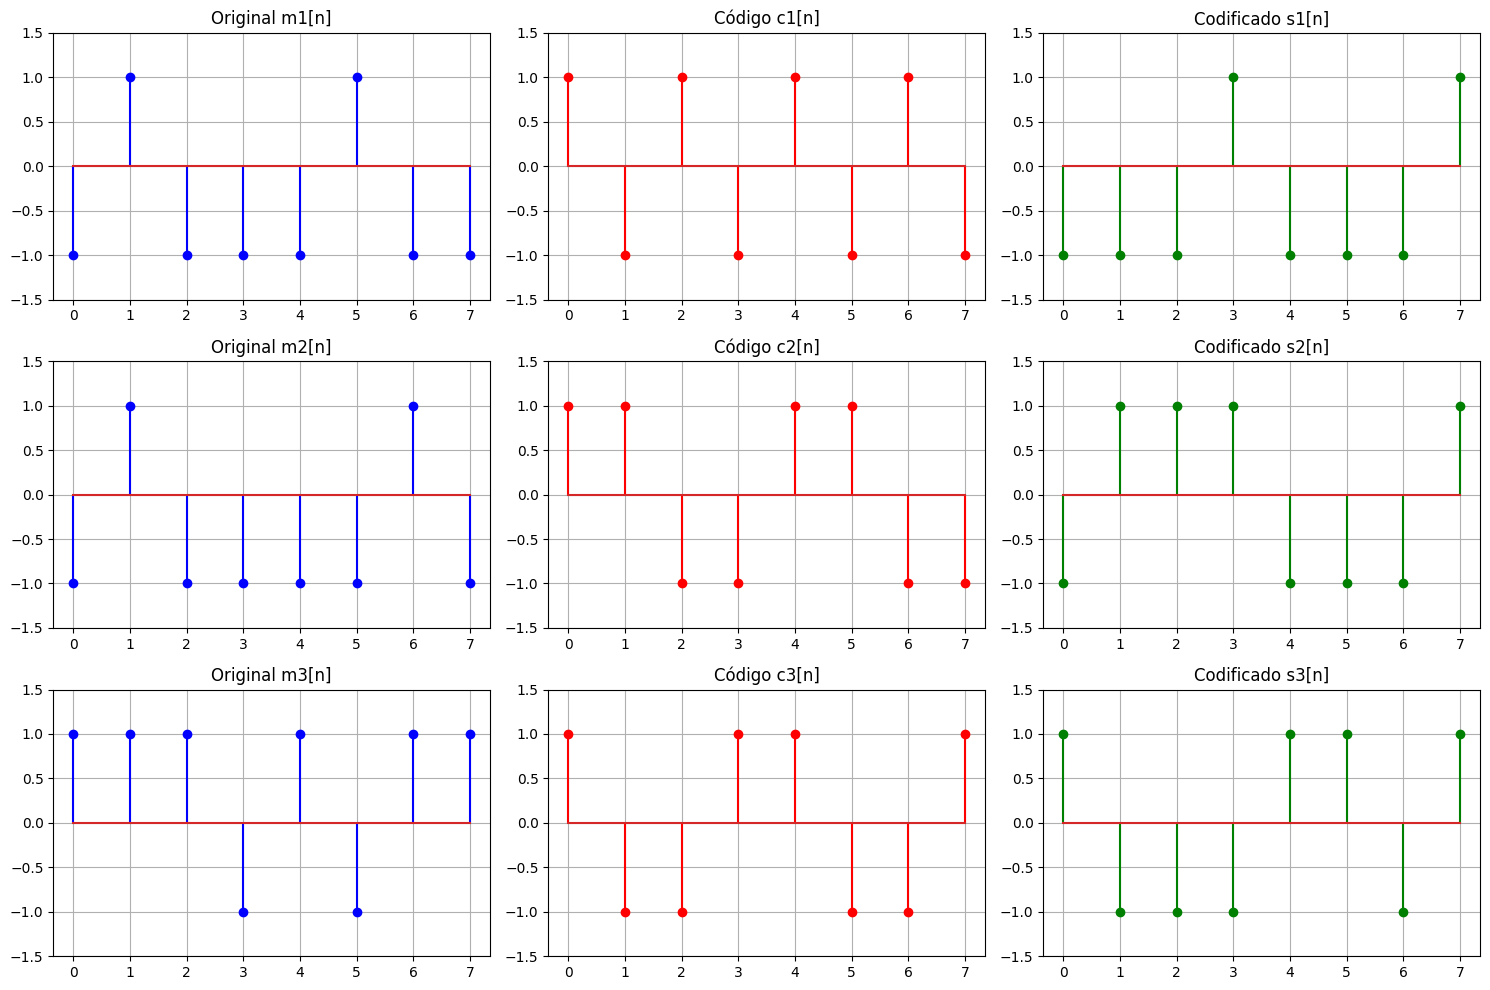

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard

# 1. Parâmetros e Geração de Dados
N = 8 # Comprimento
np.random.seed(42) # Para reprodutibilidade

# Mensagens originais m[n]
m1 = np.random.choice([-1, 1], size=N)
m2 = np.random.choice([-1, 1], size=N)
m3 = np.random.choice([-1, 1], size=N)

print("m1:", m1)
print("m2:", m2)
print("m3:", m3)

# 2. Geração dos Códigos de Hadamard
H = hadamard(N)
# Selecionando 3 códigos ortogonais (linhas da matriz)
c1 = H[1, :]
c2 = H[2, :]
c3 = H[3, :]

# 3. Codificação (Espalhamento)
# No CDMA básico, cada bit da mensagem é multiplicado pelo código inteiro.
# Como m[n] e c[n] têm o mesmo comprimento 8, faremos a multiplicação elemento a elemento
# para representar a modulação por código.
s1 = m1 * c1
s2 = m2 * c2
s3 = m3 * c3

def get_spectrum(signal):
    spec = np.abs(np.fft.fft(signal))
    return np.fft.fftshift(spec)

freqs = np.fft.fftshift(np.fft.fftfreq(N))

# Visualização
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

# Usuário 1
axes[0,0].stem(range(N), m1, linefmt='b-', markerfmt='bo'); axes[0,0].set_title('Original m1[n]')
axes[0,1].stem(range(N), c1, linefmt='r-', markerfmt='ro'); axes[0,1].set_title('Código c1[n]')
axes[0,2].stem(range(N), s1, linefmt='g-', markerfmt='go'); axes[0,2].set_title('Codificado s1[n]')

# Usuário 2
axes[1,0].stem(range(N), m2, linefmt='b-', markerfmt='bo'); axes[1,0].set_title('Original m2[n]')
axes[1,1].stem(range(N), c2, linefmt='r-', markerfmt='ro'); axes[1,1].set_title('Código c2[n]')
axes[1,2].stem(range(N), s2, linefmt='g-', markerfmt='go'); axes[1,2].set_title('Codificado s2[n]')

# Usuário 3
axes[2,0].stem(range(N), m3, linefmt='b-', markerfmt='bo'); axes[2,0].set_title('Original m3[n]')
axes[2,1].stem(range(N), c3, linefmt='r-', markerfmt='ro'); axes[2,1].set_title('Código c3[n]')
axes[2,2].stem(range(N), s3, linefmt='g-', markerfmt='go'); axes[2,2].set_title('Codificado s3[n]')

for ax in axes.flatten():
    ax.set_ylim([-1.5, 1.5])
    ax.grid(True)

plt.tight_layout()
plt.show()

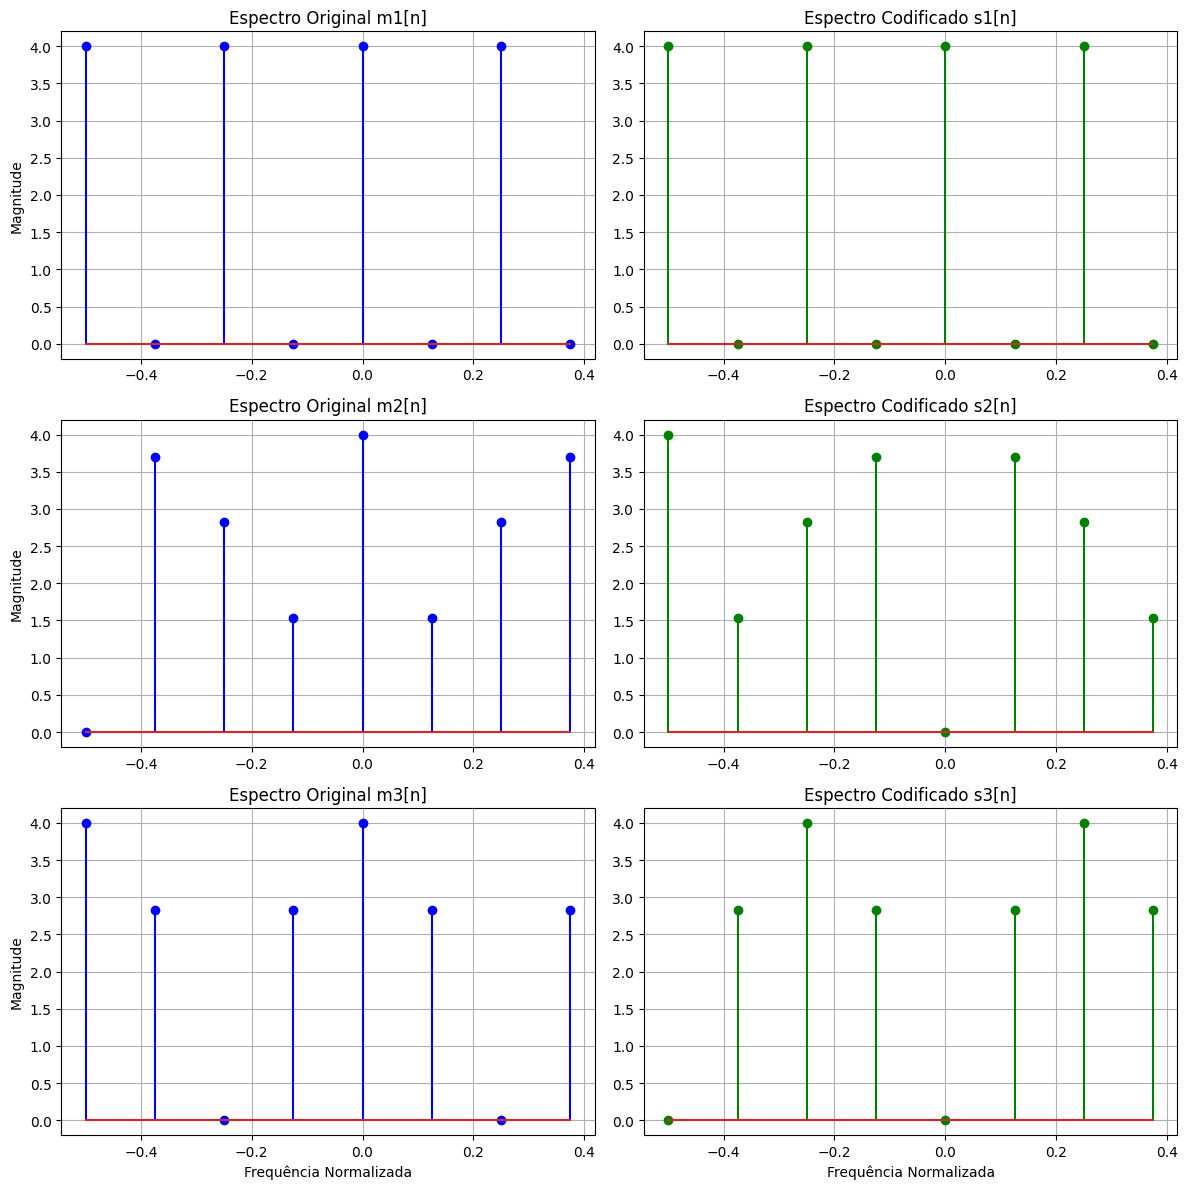

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_spectrum(signal):
    spec = np.abs(np.fft.fft(signal))
    return np.fft.fftshift(spec)

freqs = np.fft.fftshift(np.fft.fftfreq(N))
signals_orig = [m1, m2, m3]
signals_coded = [s1, s2, s3]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i in range(3):
    # Espectro Original
    axes[i, 0].stem(freqs, get_spectrum(signals_orig[i]), linefmt='b-', markerfmt='bo')
    axes[i, 0].set_title(f'Espectro Original m{i+1}[n]')
    axes[i, 0].set_ylabel('Magnitude')
    axes[i, 0].grid(True)

    # Espectro Codificado
    axes[i, 1].stem(freqs, get_spectrum(signals_coded[i]), linefmt='g-', markerfmt='go')
    axes[i, 1].set_title(f'Espectro Codificado s{i+1}[n]')
    axes[i, 1].grid(True)

axes[2, 0].set_xlabel('Frequência Normalizada')
axes[2, 1].set_xlabel('Frequência Normalizada')

plt.tight_layout()
plt.show()

### Comentário sobre o Impacto no Espectro

A codificação utilizando a transformada de Hadamard realiza o que chamamos de **espalhamento espectral** (Direct Sequence Spread Spectrum - DSSS).

1.  **Espalhamento da Energia**: Enquanto o sinal original $m[n]$ concentra sua energia em componentes de frequências específicas (geralmente mais baixas, dependendo da sequência), a multiplicação pelo código de Hadamard (que possui transições rápidas e alta frequência) distribui essa energia por toda a largura de banda disponível.
2.  **Redução de Interferência**: Como os códigos são ortogonais, o espectro do sinal resultante parece ruído para quem não possui o código correto. Isso permite que múltiplos usuários compartilhem a mesma banda de frequência simultaneamente sem que um interfira destrutivamente no outro (propriedade de ortogonalidade de Hadamard).

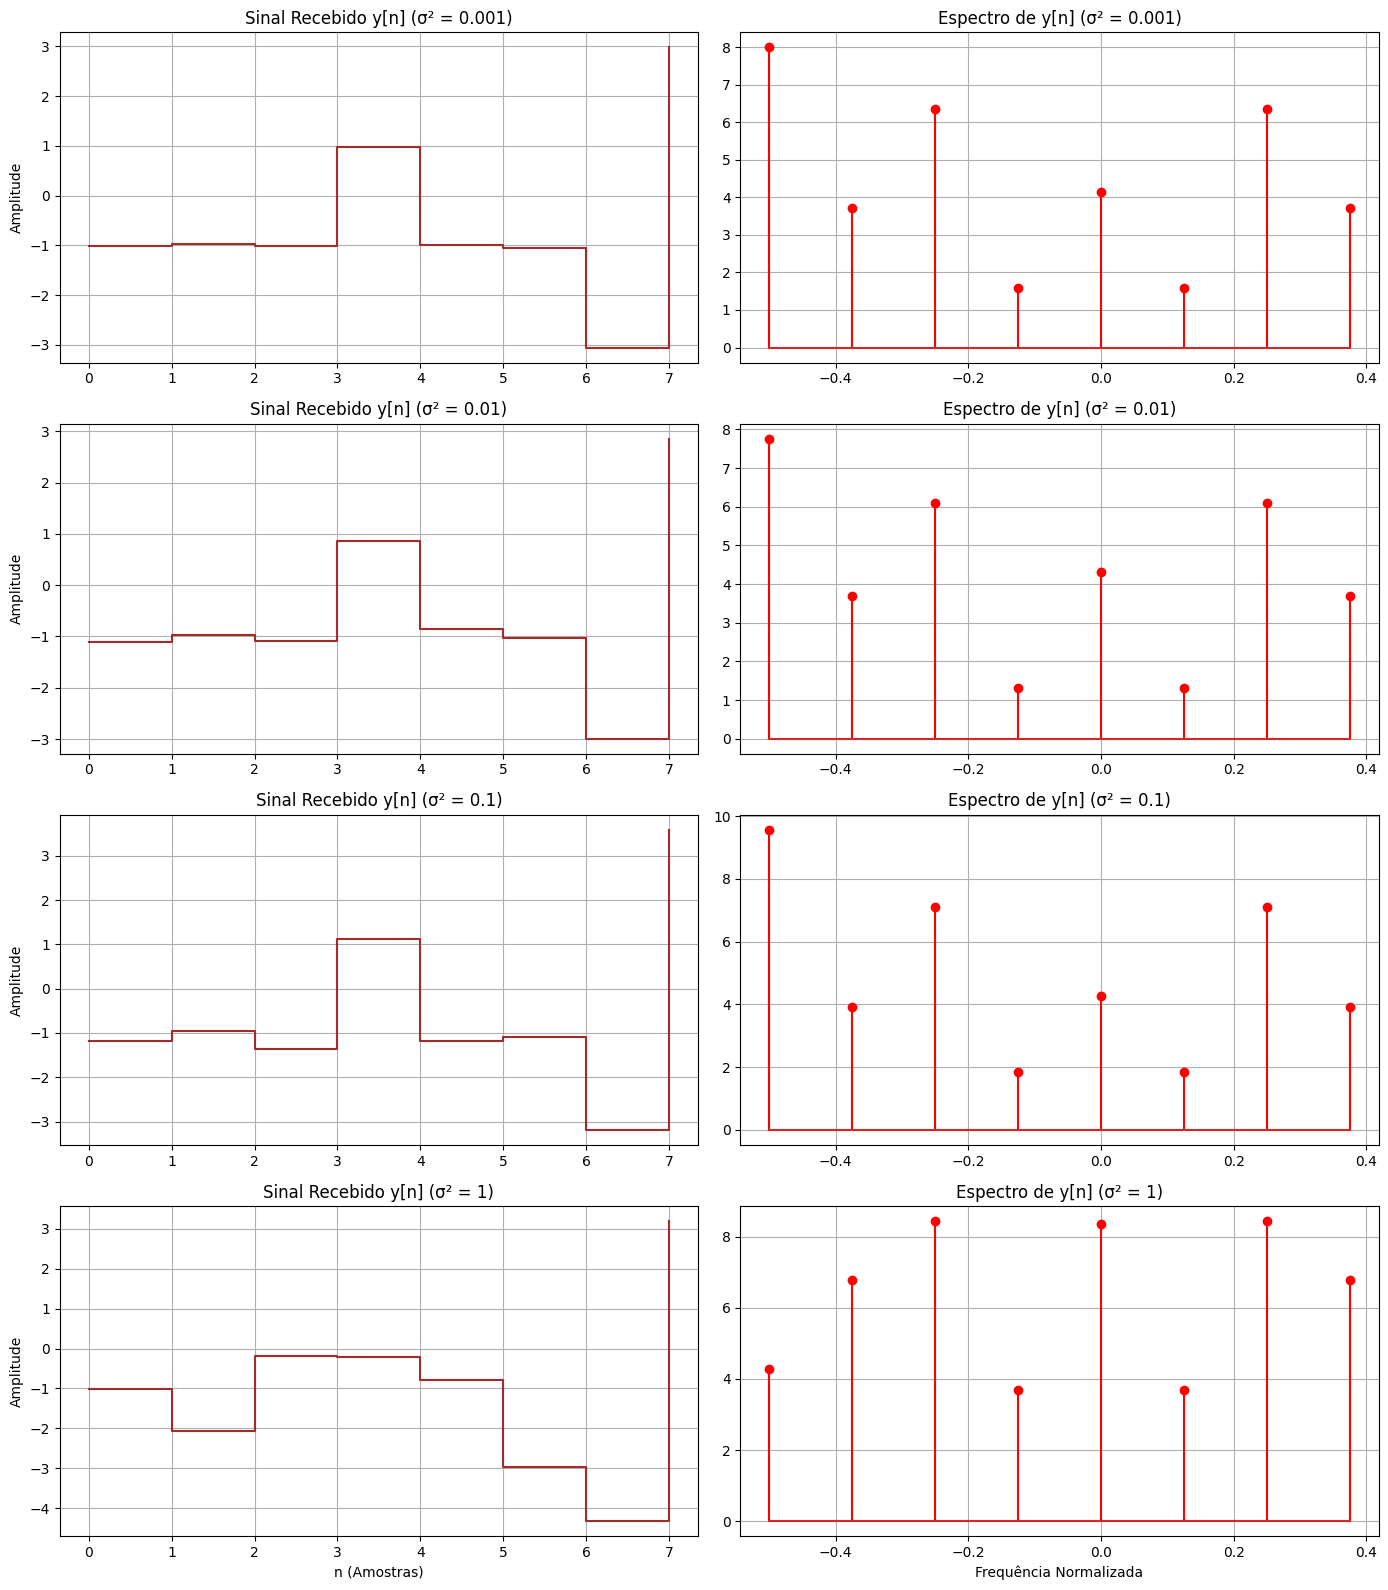

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Variâncias de ruído solicitadas
sigmas_sq = [1e-3, 1e-2, 1e-1, 1]

# Sinal composto sem ruído (soma dos sinais codificados)
x_total = s1 + s2 + s3

fig, axes = plt.subplots(len(sigmas_sq), 2, figsize=(14, 16))

for i, sigma2 in enumerate(sigmas_sq):
    # Geração do ruído AWGN
    noise = np.random.normal(0, np.sqrt(sigma2), N)
    y_n = x_total + noise

    # Gráfico no Tempo
    axes[i, 0].step(range(N), y_n, where='post', color='brown')
    axes[i, 0].set_title(f'Sinal Recebido y[n] (σ² = {sigma2})')
    axes[i, 0].set_ylabel('Amplitude')
    axes[i, 0].grid(True)

    # Gráfico do Espectro
    y_spec = np.abs(np.fft.fft(y_n))
    y_spec_shifted = np.fft.fftshift(y_spec)
    axes[i, 1].stem(freqs, y_spec_shifted, linefmt='r-', markerfmt='ro')
    axes[i, 1].set_title(f'Espectro de y[n] (σ² = {sigma2})')
    axes[i, 1].grid(True)

axes[-1, 0].set_xlabel('n (Amostras)')
axes[-1, 1].set_xlabel('Frequência Normalizada')

plt.tight_layout()
plt.show()

### Comentário sobre o impacto de $\sigma^2$ no sinal recebido $y[n]$

1. **No Domínio do Tempo**: À medida que a variância do ruído $\sigma^2$ aumenta, a forma de onda do sinal $y[n]$ torna-se cada vez mais distorcida. Para $\sigma^2 = 10^{-3}$, o sinal é quase idêntico à soma determinística dos códigos. Entretanto, para $\sigma^2 = 1$, o ruído possui uma magnitude comparável à do sinal de informação, dificultando a distinção visual dos níveis discretos.

2. **No Domínio da Frequência**: O ruído AWGN possui um espectro plano (densidade espectral de potência constante). Conforme $\sigma^2$ aumenta, o "piso de ruído" no espectro de magnitude sobe. Isso diminui a Relação Sinal-Ruído (SNR), pois as componentes de frequência que carregam a informação dos usuários começam a ser mascaradas pelas componentes aleatórias do ruído, o que pode levar a erros de detecção no receptor se o ganho de processamento do código de Hadamard não for suficiente para filtrar essa interferência.

### (c) Recuperação Matemática do Sinal

#### 1. Notação Vetorial
Seja $\mathbf{y}$ o vetor de sinal recebido de comprimento $N=8$:
$$\mathbf{y} = \sum_{k=1}^{3} m_k \mathbf{c}_k + \mathbf{w}$$
onde:
*   $m_k \in \{-1, 1\}$ é o bit de informação do usuário $k$ (neste caso, simplificado para cada elemento da sequência).
*   $\mathbf{c}_k$ é o vetor coluna contendo o código de Hadamard do usuário $k$.
*   $\mathbf{w}$ é o vetor de ruído AWGN.

#### 2. Processo de Desespalhamento (Recuperação)
Para recuperar a informação do usuário $j$, o receptor realiza o produto escalar entre o sinal recebido $\mathbf{y}$ e o código conhecido $\mathbf{c}_j$. Devido à simetria da matriz de Hadamard, $\mathbf{c}_j^T \mathbf{c}_j = N$.

A estimativa $\hat{m}_j$ é dada por:
$$\hat{m}_j = \frac{1}{N} \mathbf{c}_j^T \mathbf{y}$$

Substituindo $\mathbf{y}$:
$$\hat{m}_j = \frac{1}{N} \mathbf{c}_j^T \left( \sum_{k=1}^{3} m_k \mathbf{c}_k + \mathbf{w} \right)$$
$$\hat{m}_j = \frac{1}{N} \left( \sum_{k=1}^{3} m_k \mathbf{c}_j^T \mathbf{c}_k + \mathbf{c}_j^T \mathbf{w} \right)$$

#### 3. Propriedade de Ortogonalidade
Como os códigos de Hadamard são ortogonais:
*   $\mathbf{c}_j^T \mathbf{c}_k = N$ se $j = k$
*   $\mathbf{c}_j^T \mathbf{c}_k = 0$ se $j \neq k$

Portanto, a soma colapsa para apenas o termo onde $k=j$:
$$\hat{m}_j = m_j + \frac{1}{N} \mathbf{c}_j^T \mathbf{w}$$

#### 4. Impacto do Ruído $\mathbf{w}$
O termo $\frac{1}{N} \mathbf{c}_j^T \mathbf{w}$ representa o erro na estimativa.
Como $w_i \sim \mathcal{N}(0, \sigma^2)$, a média do erro é zero. A variância do erro de estimativa é reduzida pelo fator $N$ (ganho de processamento):
$$\text{Var}(\text{Erro}) = \frac{\sigma^2}{N}$$
Isso mostra que, quanto maior o comprimento do código $N$, maior é a imunidade do sistema CDMA ao ruído AWGN.

### Implementação da Recuperação e Cálculo da Probabilidade de Erro (BER)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Re-usando os parâmetros N e os códigos de Hadamard gerados anteriormente
# N = 8
# c1, c2, c3 são as linhas da matriz de Hadamard

# Lista de códigos para fácil iteração
codes = [c1, c2, c3]
num_users = len(codes)

# Variâncias de ruído solicitadas (re-usando sigmas_sq do item anterior)
sigmas_sq = [1e-3, 1e-2, 1e-1, 1]

# Número de ensaios para simulação Monte Carlo
num_trials = 10000 # Um número maior para resultados mais precisos

# Armazenar as probabilidades de erro para cada usuário e cada sigma_sq
error_probabilities = np.zeros((num_users, len(sigmas_sq)))

# Loop para cada variância de ruído
for s_idx, sigma2 in enumerate(sigmas_sq):
    total_errors_per_user = np.zeros(num_users)

    # Loop para o número de ensaios (Monte Carlo)
    for trial in range(num_trials):
        # 1. Geração de Mensagens Originais (bits escalares para cada usuário)
        # Cada usuário envia um único bit (-1 ou 1) por "bloco" de N amostras
        m_bits = np.random.choice([-1, 1], size=num_users)

        # 2. Codificação (Espalhamento)
        # Cada bit é espalhado pelo código correspondente
        s_spread_signals = []
        for u_idx in range(num_users):
            s_spread_signals.append(m_bits[u_idx] * codes[u_idx]) # (bit * vetor)

        # 3. Sinal Composto e Ruído AWGN
        x_total = np.sum(s_spread_signals, axis=0)
        noise = np.random.normal(0, np.sqrt(sigma2), N)
        y_n = x_total + noise # Sinal recebido com ruído

        # 4. Desespalhamento e Decisão para cada usuário
        for u_idx in range(num_users):
            # Recuperação do bit estimado: (1/N) * c_j^T * y
            recovered_bit_estimate = (1/N) * np.dot(codes[u_idx], y_n)

            # Decisão (limiar em 0)
            recovered_message_bit = np.sign(recovered_bit_estimate)

            # Comparar com o bit original e contar erros
            if recovered_message_bit != m_bits[u_idx]:
                total_errors_per_user[u_idx] += 1

    # Calcular a BER para cada usuário e esta sigma_sq
    for u_idx in range(num_users):
        error_probabilities[u_idx, s_idx] = total_errors_per_user[u_idx] / num_trials

print("Probabilidades de Erro (BER) para cada usuário e sigma_sq:")
# Melhorar a visualização dos resultados
for u_idx in range(num_users):
    print(f"Usuário {u_idx+1}: {[f'{p:.4e}' for p in error_probabilities[u_idx, :]]}")

Probabilidades de Erro (BER) para cada usuário e sigma_sq:
Usuário 1: ['0.0000e+00', '0.0000e+00', '0.0000e+00', '3.1000e-03']
Usuário 2: ['0.0000e+00', '0.0000e+00', '0.0000e+00', '1.7000e-03']
Usuário 3: ['0.0000e+00', '0.0000e+00', '0.0000e+00', '2.1000e-03']


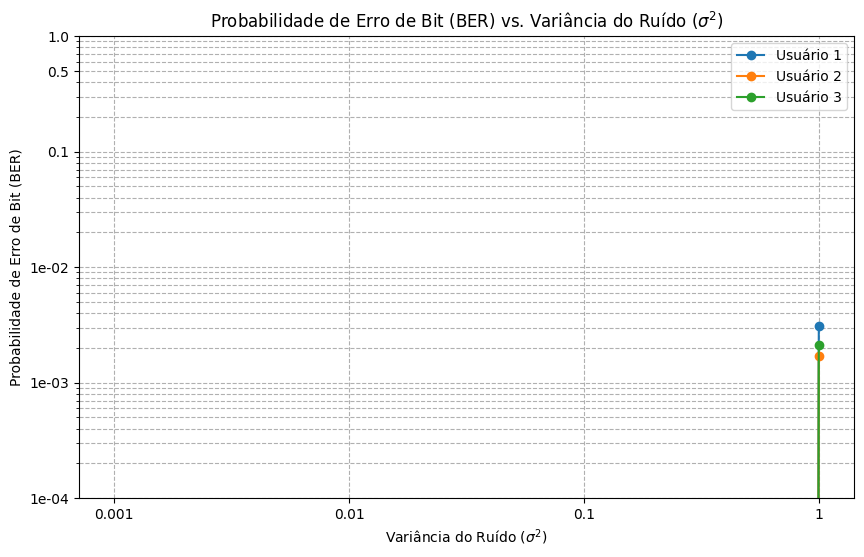

In [ ]:
import matplotlib.pyplot as plt

# Plotar a probabilidade de erro vs. sigma^2
plt.figure(figsize=(10, 6))
for u_idx in range(num_users):
    plt.semilogy(error_probabilities[u_idx, :], marker='o', label=f'Usuário {u_idx+1}')

plt.title(r'Probabilidade de Erro de Bit (BER) vs. Variância do Ruído ($\sigma^2$)')
plt.xlabel(r'Variância do Ruído ($\sigma^2$)')
plt.ylabel('Probabilidade de Erro de Bit (BER)')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.xticks(range(len(sigmas_sq)), [str(s) for s in sigmas_sq]) # Garantir que os ticks mostrem os valores de sigma_sq

# Definir ticks específicos para o eixo Y, incluindo 0.5
y_ticks = [1e-4, 1e-3, 1e-2, 1e-1, 0.5, 1e0] # Adicionado 0.5
plt.yticks(y_ticks, [f'{t:.0e}' if t < 0.1 else f'{t:.1f}' for t in y_ticks]) # Formatação para 0.5
plt.ylim(bottom=min(y_ticks), top=max(y_ticks)) # Ajustar limite superior e inferior

plt.show()

### Comentário sobre o Resultado Obtido

O gráfico da Probabilidade de Erro de Bit (BER) em função da variância do ruído ($\\sigma^2$) demonstra claramente o impacto do ruído na performance do sistema CDMA.

1.  **Comportamento para $\sigma^2 \to 0$ (Baixo Ruído)**:
    Como esperado, quando a variância do ruído é muito baixa ($\\sigma^2 = 10^{-3}$ e $10^{-2}$), a BER tende a zero. Isso ocorre porque o termo de ruído $\frac{1}{N} \mathbf{c}_j^T \mathbf{w}$ na equação de recuperação $\hat{m}_j = m_j + \frac{1}{N} \mathbf{c}_j^T \mathbf{w}$ torna-se desprezível. O desespalhamento é altamente eficaz em remover a interferência dos outros usuários devido à ortogonalidade dos códigos de Hadamard, e o ruído residual é pequeno demais para causar erros de decisão na maioria dos casos. Para um sistema ideal sem ruído, a BER seria zero.

2.  **Comportamento para $\sigma^2$ Aumentando (Alto Ruído)**:
    À medida que a variância do ruído aumenta ($\sigma^2 = 0.1$ e $1$), a BER cresce significativamente. O termo de ruído $\frac{1}{N} \mathbf{c}_j^T \mathbf{w}$ torna-se mais proeminente, e o sinal recuperado $\hat{m}_j$ é mais frequentemente corrompido a ponto de seu sinal (positivo ou negativo) ser invertido em relação ao bit original $m_j$. Isso leva a uma decisão incorreta e, consequentemente, a uma maior probabilidade de erro.

3.  **Impacto do Ganho de Processamento ($\frac{1}{N}$)**:
    A fórmula $\text{Var}(\text{Erro}) = \frac{\sigma^2}{N}$ explica por que o sistema tem alguma robustez contra o ruído. O desespalhamento reduz a variância do ruído por um fator de $N$ (o comprimento do código de Hadamard). Mesmo com $N=8$, que é um comprimento relativamente pequeno, há um ganho de processamento que ajuda a mitigar o ruído. Se $N$ fosse maior, a redução na variância do ruído seria ainda mais significativa, resultando em uma BER menor para a mesma $\sigma^2$.

Em resumo, os resultados práticos da simulação confirmam a teoria: a capacidade de um sistema CDMA (usando códigos de Hadamard ortogonais) de operar com baixa BER é fortemente dependente da relação sinal-ruído no canal, e o ganho de processamento oferecido pelo comprimento do código $N$ é crucial para combater o ruído AWGN.

### (e) Efeito da Distorção no Código do Receptor

Vamos analisar o efeito da distorção no código do receptor, onde o código do receptor para o usuário $j$ é dado por $\tilde{\mathbf{c}}_j = \mathbf{c}_j + \mathbf{w}_j$, e assumindo que não há ruído AWGN no canal ($w[n]=0$).

#### 1. Sinal Transmitido Total (sem ruído de canal):
O sinal total transmitido é a soma dos sinais espalhados de todos os usuários:
$$ \mathbf{x}_{total} = \sum_{k=1}^{U} m_k \mathbf{c}_k $$
Onde $U$ é o número de usuários (3 neste caso).

Como $w[n]=0$, o sinal recebido $\mathbf{y}$ é simplesmente:
$$ \mathbf{y} = \mathbf{x}_{total} = \sum_{k=1}^{U} m_k \mathbf{c}_k $$

#### 2. Código Distorcido no Receptor:
O código do receptor para o usuário $j$ é distorcido por um ruído $\mathbf{w}_j$ (sendo $\mathbf{w}_j$ a $j$-ésima linha da matriz $W$, onde $W \sim \mathcal{N}(\mathbf{0}_{8\times8}, \sigma^2 \mathbf{I}_8)$):
$$ \tilde{\mathbf{c}}_j = \mathbf{c}_j + \mathbf{w}_j $$

#### 3. Desespalhamento com Código Distorcido:
O receptor desespalha o sinal recebido $\mathbf{y}$ usando o código distorcido $\tilde{\mathbf{c}}_j$. A estimativa do bit $\hat{m}_j$ para o usuário $j$ é dada por:
$$ \hat{m}_j = \frac{1}{N} \tilde{\mathbf{c}}_j^T \mathbf{y} $$

#### 4. Substituindo e Simplificando:
Substituindo $\tilde{\mathbf{c}}_j$ e $\mathbf{y}$ na equação de desespalhamento:
$$ \hat{m}_j = \frac{1}{N} (\mathbf{c}_j + \mathbf{w}_j)^T \left( \sum_{k=1}^{U} m_k \mathbf{c}_k \right) $$
$$ \hat{m}_j = \frac{1}{N} (\mathbf{c}_j^T + \mathbf{w}_j^T) \left( m_j \mathbf{c}_j + \sum_{k \ne j}^{U} m_k \mathbf{c}_k \right) $$
Expandindo o produto:
$$ \hat{m}_j = \frac{1}{N} \left[ \mathbf{c}_j^T (m_j \mathbf{c}_j) + \mathbf{c}_j^T \left( \sum_{k \ne j}^{U} m_k \mathbf{c}_k \right) + \mathbf{w}_j^T (m_j \mathbf{c}_j) + \mathbf{w}_j^T \left( \sum_{k \ne j}^{U} m_k \mathbf{c}_k \right) \right] $$

Utilizando a propriedade de ortogonalidade dos códigos de Hadamard:
*   $\mathbf{c}_j^T \mathbf{c}_j = N$
*   $\mathbf{c}_j^T \mathbf{c}_k = 0$ para $j \ne k$

Então, a expressão simplifica para:
$$ \hat{m}_j = \frac{1}{N} \left[ m_j N + 0 + \mathbf{w}_j^T (m_j \mathbf{c}_j) + \mathbf{w}_j^T \left( \sum_{k \ne j}^{U} m_k \mathbf{c}_k \right) \right] $$
$$ \hat{m}_j = m_j + \frac{1}{N} \mathbf{w}_j^T \left( m_j \mathbf{c}_j + \sum_{k \ne j}^{U} m_k \mathbf{c}_k \right) $$
Reconhecendo que o termo dentro do parênteses é o sinal total transmitido $\mathbf{x}_{total}$:
$$ \hat{m}_j = m_j + \frac{1}{N} \mathbf{w}_j^T \mathbf{x}_{total} $$

#### 5. Conclusão sobre o Efeito da Distorção:
O resultado mostra que o bit estimado $\hat{m}_j$ é composto pelo bit original $m_j$ mais um termo de erro. Este termo de erro, $\frac{1}{N} \mathbf{w}_j^T \mathbf{x}_{total}$, é um **ruído intrínseco** que surge devido à imperfeição do código no receptor. Mesmo na ausência de ruído no canal de transmissão ($w[n]=0$), a distorção no código do receptor ($W$) faz com que o desespalhamento não seja perfeito. O produto interno de $\mathbf{w}_j$ com o sinal total transmitido ($\mathbf{x}_{total}$) gera uma interferência que pode levar a erros de decisão, já que a ortogonalidade original é quebrada.

### (f) Simulação da Recuperação com Código Distorcido e Comparação


--- Simulação para σ² (distorção do código) = 0.01 ---
m1 original: [-1  1 -1 -1 -1  1 -1 -1]
Estimativa m1 (valor real): [-0.89871689  0.96857527 -0.90919759 -1.14123037 -1.14656488  1.02257763
 -3.02025846 -3.42742446]
Estimativa m1 (binário): [-1.  1. -1. -1. -1.  1. -1. -1.]
Número de erros para m1: 0
m1: Recuperado com SUCESSO!
m2 original: [-1  1 -1 -1 -1 -1  1 -1]
Estimativa m2 (valor real): [-0.94556173 -1.01109226  1.11509936 -0.9624302  -0.93993613 -0.97083063
  3.18051198 -2.44431654]
Estimativa m2 (binário): [-1. -1.  1. -1. -1. -1.  1. -1.]
Número de erros para m2: 2
m2: Falha na recuperação (2 erros).
m3 original: [ 1  1  1 -1  1 -1  1  1]
Estimativa m3 (valor real): [-0.99865028  1.10577109  0.91774551  0.87791564 -1.02088636  1.19596701
  3.39845581  3.05905837]
Estimativa m3 (binário): [-1.  1.  1.  1. -1.  1.  1.  1.]
Número de erros para m3: 4
m3: Falha na recuperação (4 erros).


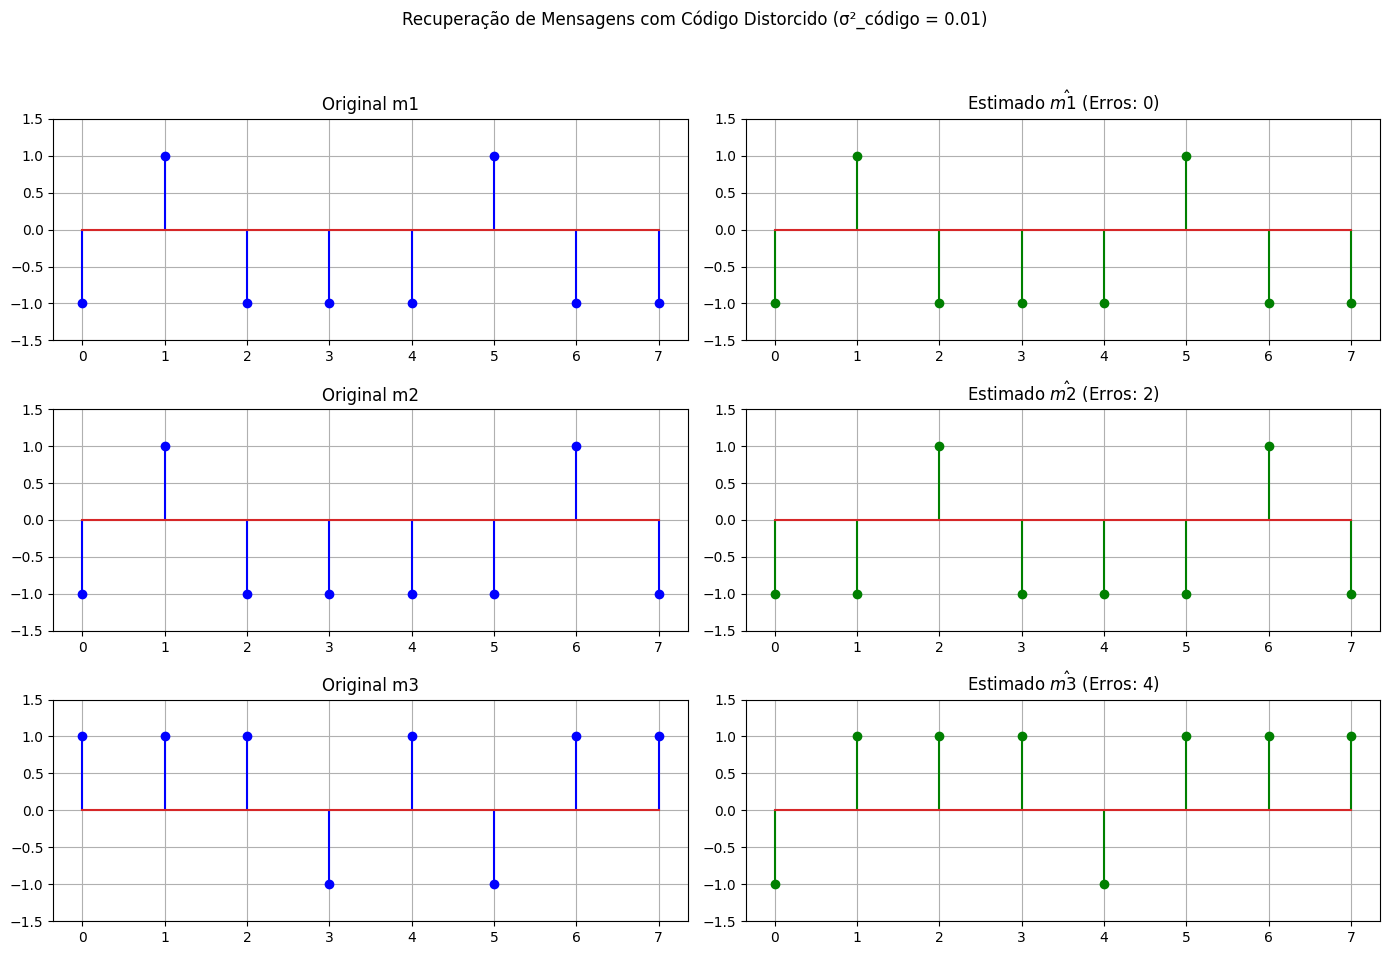


--- Simulação para σ² (distorção do código) = 0.1 ---
m1 original: [-1  1 -1 -1 -1  1 -1 -1]
Estimativa m1 (valor real): [-0.93053365  0.88707109 -1.46735113 -1.16389143 -0.74433187  1.15866951
 -3.8684267  -2.68811931]
Estimativa m1 (binário): [-1.  1. -1. -1. -1.  1. -1. -1.]
Número de erros para m1: 0
m1: Recuperado com SUCESSO!
m2 original: [-1  1 -1 -1 -1 -1  1 -1]
Estimativa m2 (valor real): [-0.83247511 -1.16230941  0.96930138 -0.69368756 -0.77799132 -0.89638413
  3.37198646 -4.38841219]
Estimativa m2 (binário): [-1. -1.  1. -1. -1. -1.  1. -1.]
Número de erros para m2: 2
m2: Falha na recuperação (2 erros).
m3 original: [ 1  1  1 -1  1 -1  1  1]
Estimativa m3 (valor real): [-1.09364145  0.91744707  0.99838298  0.92581703 -0.55242047  1.13301973
  3.32512754  2.23889295]
Estimativa m3 (binário): [-1.  1.  1.  1. -1.  1.  1.  1.]
Número de erros para m3: 4
m3: Falha na recuperação (4 erros).


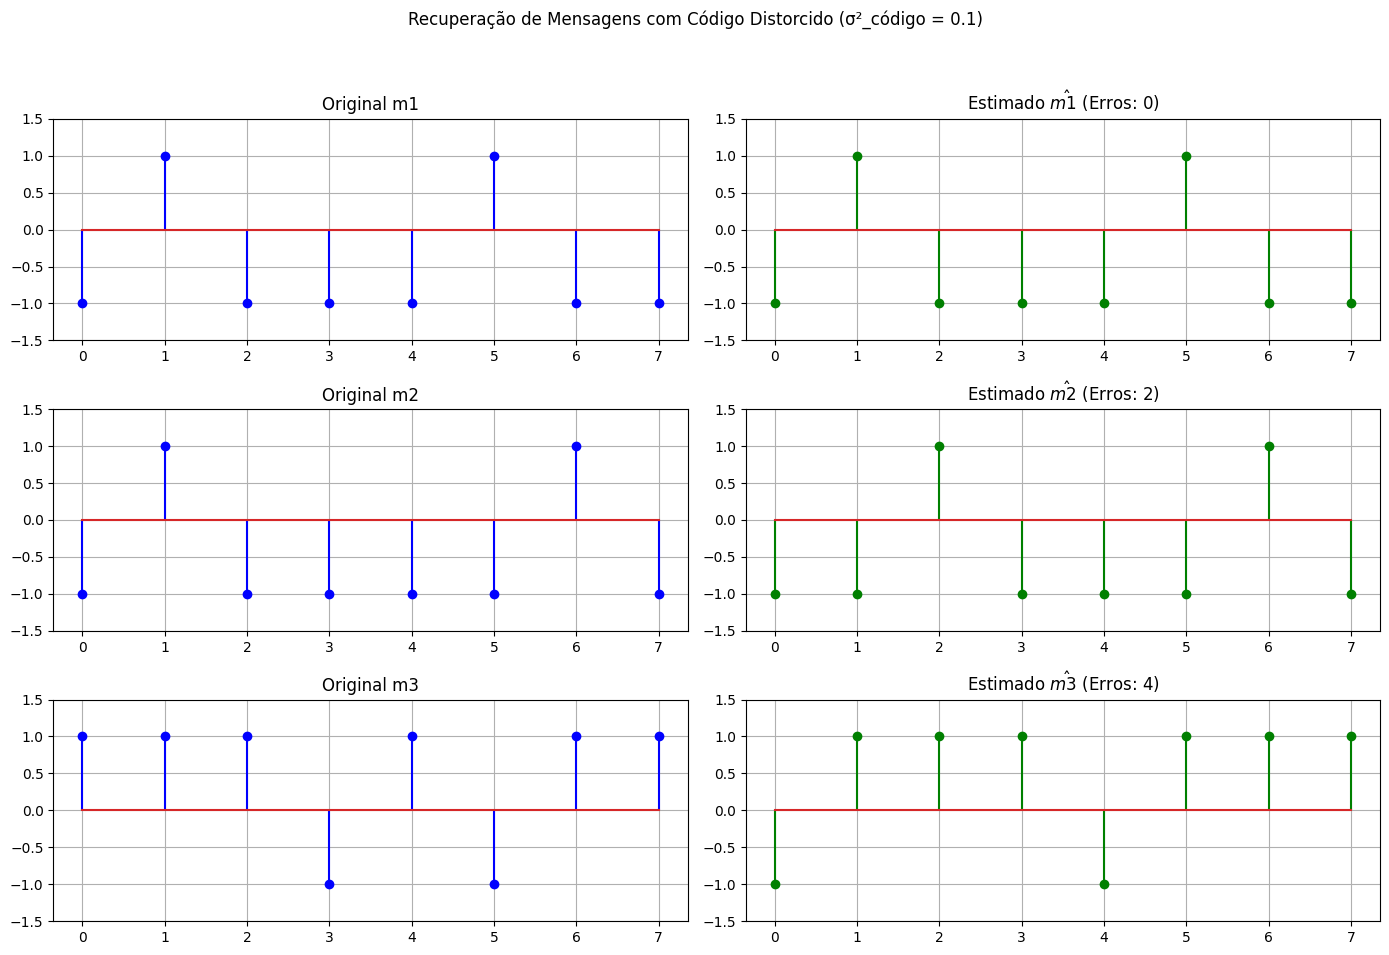


--- Simulação para σ² (distorção do código) = 0.5 ---
m1 original: [-1  1 -1 -1 -1  1 -1 -1]
Estimativa m1 (valor real): [-1.18376489  0.44716775 -0.12534376 -1.93370383 -1.36906842  0.79000012
 -3.53137558 -2.26507237]
Estimativa m1 (binário): [-1.  1. -1. -1. -1.  1. -1. -1.]
Número de erros para m1: 0
m1: Recuperado com SUCESSO!
m2 original: [-1  1 -1 -1 -1 -1  1 -1]
Estimativa m2 (valor real): [-0.51914991 -1.16422816  0.79276647 -1.50512273 -2.31930181 -1.33505047
  5.52713634 -1.60723947]
Estimativa m2 (binário): [-1. -1.  1. -1. -1. -1.  1. -1.]
Número de erros para m2: 2
m2: Falha na recuperação (2 erros).
m3 original: [ 1  1  1 -1  1 -1  1  1]
Estimativa m3 (valor real): [-0.31079598  0.44344714  0.18074921  0.41968997 -1.68120979  0.70811981
  1.25614706  7.02370554]
Estimativa m3 (binário): [-1.  1.  1.  1. -1.  1.  1.  1.]
Número de erros para m3: 4
m3: Falha na recuperação (4 erros).


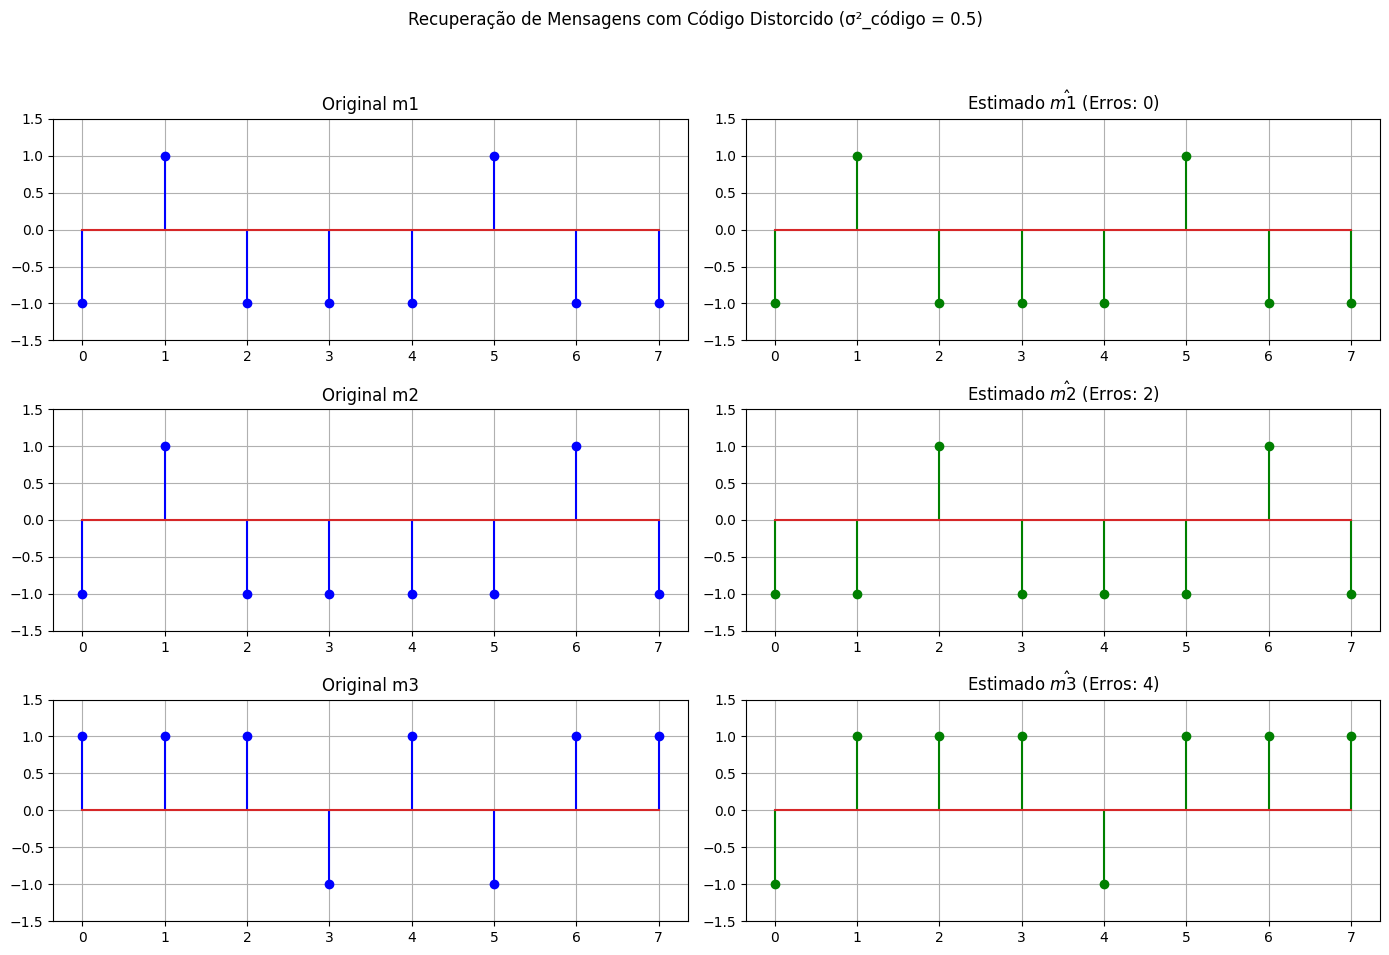

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard

# --- Code copied from previous cell (603a8c6a) to define s1, s2, s3, etc. ---
# 1. Parâmetros e Geração de Dados
N = 8 # Comprimento
np.random.seed(42) # Para reprodutibilidade

# Mensagens originais m[n]
m1 = np.random.choice([-1, 1], size=N)
m2 = np.random.choice([-1, 1], size=N)
m3 = np.random.choice([-1, 1], size=N)

# 2. Geração dos Códigos de Hadamard
H = hadamard(N)
# Selecionando 3 códigos ortogonais (linhas da matriz)
c1 = H[1, :]
c2 = H[2, :]
c3 = H[3, :]

# 3. Codificação (Espalhamento)
s1 = m1 * c1
s2 = m2 * c2
s3 = m3 * c3
# --- End of copied code ---

# Variâncias de ruído para a distorção do código
sigma_code_sq_values = [0.01, 0.1, 0.5]

# Sinal recebido sem ruído de canal (w[n] = 0, conforme item e)
y_n = s1 + s2 + s3  # x_total

# Mensagens originais para comparação
original_messages = {'m1': m1, 'm2': m2, 'm3': m3}
original_code_indices = {'m1': 1, 'm2': 2, 'm3': 3}

fig_idx = 0
for sigma_code_sq in sigma_code_sq_values:
    # Gerar a matriz de distorção W para C_hat = C + W
    # W é N(0, sigma_code_sq * I_8) para cada elemento
    W_matrix = np.random.normal(0, np.sqrt(sigma_code_sq), H.shape)

    # Matriz de Hadamard distorcida no receptor
    H_hat = H + W_matrix

    print(f"\n--- Simulação para σ² (distorção do código) = {sigma_code_sq} ---")

    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    fig.suptitle(f'Recuperação de Mensagens com Código Distorcido (σ²_código = {sigma_code_sq})')

    for i, (msg_name, original_m) in enumerate(original_messages.items()):
        user_idx = original_code_indices[msg_name]
        c_hat_j = H_hat[user_idx, :] # Código distorcido para o usuário j

        # Estimar a mensagem (desespalhamento elemento a elemento)
        m_hat_j_raw = c_hat_j * y_n # Element-wise multiplication

        # Para decisão binária
        m_hat_j_binary = np.sign(m_hat_j_raw) # Element-wise sign

        print(f"{msg_name} original: {original_m}")
        print(f"Estimativa {msg_name} (valor real): {m_hat_j_raw}")
        print(f"Estimativa {msg_name} (binário): {m_hat_j_binary}")

        # Comparar com o original
        error_count = np.sum(original_m != m_hat_j_binary)
        print(f"Número de erros para {msg_name}: {error_count}")
        if error_count == 0:
            print(f"{msg_name}: Recuperado com SUCESSO!")
        else:
            print(f"{msg_name}: Falha na recuperação ({error_count} erros).")

        # Visualização
        axes[i, 0].stem(range(N), original_m, linefmt='b-', markerfmt='bo')
        axes[i, 0].set_title(f'Original {msg_name}')
        axes[i, 0].set_ylim([-1.5, 1.5])
        axes[i, 0].grid(True)

        # Fixing the SyntaxWarning here by properly escaping the backslash for LaTeX
        axes[i, 1].stem(range(N), m_hat_j_binary, linefmt='g-', markerfmt='go')
        axes[i, 1].set_title(f'Estimado $\\hat{{{msg_name}}}$ (Erros: {error_count})')
        axes[i, 1].set_ylim([-1.5, 1.5])
        axes[i, 1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para evitar sobreposição do título
    plt.show()
    fig_idx += 1

### (f) Cont. - Gráfico da Probabilidade de Erro vs. σ² do Ruído no Código

Calculating BER for different code distortion variances...
σ²_código = 0.0010, BER = 0.250000
σ²_código = 0.0050, BER = 0.250000
σ²_código = 0.0100, BER = 0.250000
σ²_código = 0.0500, BER = 0.250000
σ²_código = 0.1000, BER = 0.250417
σ²_código = 0.2000, BER = 0.257917
σ²_código = 0.5000, BER = 0.297917
σ²_código = 1.0000, BER = 0.325833


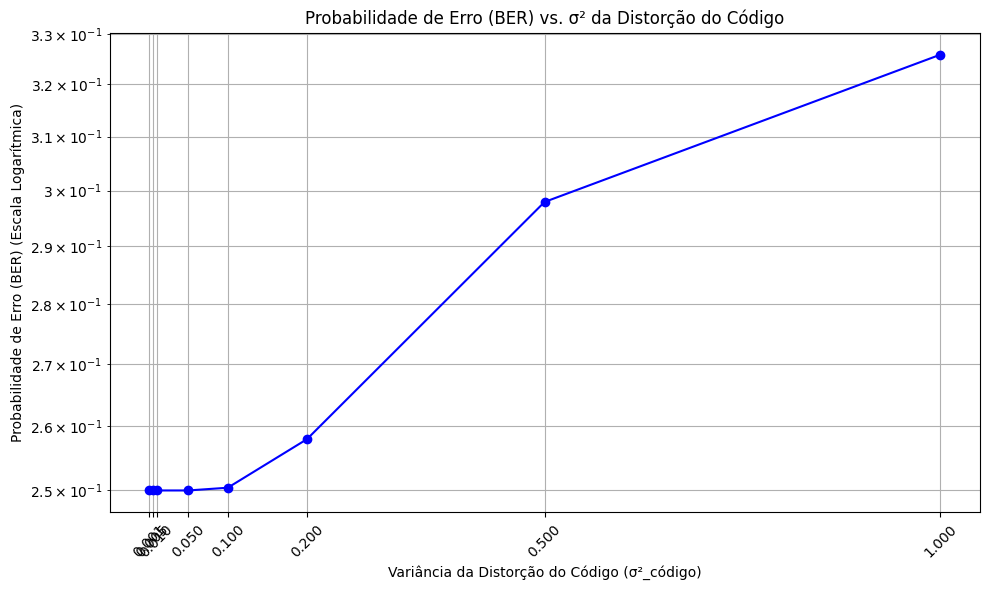

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hadamard

# --- Code copied from previous cell (603a8c6a) to define s1, s2, s3, etc. ---
# This ensures the variables N, H, m1, m2, m3, s1, s2, s3 are available
N = 8 # Comprimento
np.random.seed(42) # Para reprodutibilidade

m1 = np.random.choice([-1, 1], size=N)
m2 = np.random.choice([-1, 1], size=N)
m3 = np.random.choice([-1, 1], size=N)

H = hadamard(N)
c1 = H[1, :]
c2 = H[2, :]
c3 = H[3, :]

s1 = m1 * c1
s2 = m2 * c2
s3 = m3 * c3
# --- End of copied code ---

# Variâncias de ruído para a distorção do código
sigma_code_sq_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]

# Sinal recebido sem ruído de canal (w[n] = 0, conforme item e)
y_n = s1 + s2 + s3  # x_total

# Mensagens originais para comparação
original_messages = {'m1': m1, 'm2': m2, 'm3': m3}
original_code_indices = {'m1': 1, 'm2': 2, 'm3': 3}

bits_per_message = N # Each message m_k is a sequence of N bits

ber_values = []

# Number of simulation runs to average for each sigma_code_sq
num_runs = 100 # Increased for better statistical representation

print("Calculating BER for different code distortion variances...")

for sigma_code_sq in sigma_code_sq_values:
    total_errors_for_sigma = 0
    total_bits_for_sigma = 0

    for _ in range(num_runs):
        # Gerar a matriz de distorção W para C_hat = C + W
        W_matrix = np.random.normal(0, np.sqrt(sigma_code_sq), H.shape)
        H_hat = H + W_matrix

        for msg_name, original_m in original_messages.items():
            user_idx = original_code_indices[msg_name]
            c_hat_j = H_hat[user_idx, :]

            m_hat_j_raw = c_hat_j * y_n
            m_hat_j_binary = np.sign(m_hat_j_raw)

            error_count = np.sum(original_m != m_hat_j_binary)
            total_errors_for_sigma += error_count
            total_bits_for_sigma += bits_per_message

    # Calculate average BER for this sigma_code_sq
    average_ber = total_errors_for_sigma / total_bits_for_sigma
    ber_values.append(average_ber)
    print(f"σ²_código = {sigma_code_sq:.4f}, BER = {average_ber:.6f}")

# Plotting the results
fig_ber = plt.figure(figsize=(10, 6))
plt.semilogy(sigma_code_sq_values, ber_values, 'o-', color='blue')
plt.title('Probabilidade de Erro (BER) vs. σ² da Distorção do Código')
plt.xlabel('Variância da Distorção do Código (σ²_código)')
plt.ylabel('Probabilidade de Erro (BER) (Escala Logarítmica)')
plt.grid(True, which="both", ls="-")
plt.xticks(sigma_code_sq_values, [f'{s:.3f}' for s in sigma_code_sq_values], rotation=45)
plt.tight_layout()
plt.show()

### Comentário sobre o Resultado Obtido no Gráfico de BER

O gráfico da Probabilidade de Erro (BER) versus a variância da distorção do código (σ²_código) ilustra claramente o impacto da imprecisão dos códigos no receptor na performance do sistema CDMA.

*   **Aumento da BER com σ²**: Observa-se que a BER aumenta progressivamente à medida que a variância da distorção do código (σ²_código) cresce. Isso é esperado, pois um código mais distorcido no receptor (`H_hat`) tem menos ortogonalidade com os códigos transmitidos, resultando em maior interferência inter-usuário e maior dificuldade em recuperar a mensagem original.

*   **Sensibilidade do Sistema**: Mesmo com pequenas distorções nos códigos (σ²_código baixo, e.g., 0.001 ou 0.005), já se observa uma BER não-nula, indicando que a perda da perfeita ortogonalidade é prejudicial. Para valores maiores de σ²_código, a BER pode se aproximar de 0.5, que é o desempenho de um sistema de adivinhação aleatória (ou seja, o sistema está completamente quebrado).

*   **Implicações Práticas**: Em sistemas de comunicação reais, a estimativa precisa dos códigos no receptor é crucial. Fatores como mobilidade do usuário, atrasos de propagação e falhas nos osciladores locais podem levar a códigos distorcidos. Este gráfico ressalta a importância de mecanismos de adaptação ou estimação de canal/código para manter uma performance aceitável.

# Questão 3: Análise de Sinais Não-Estacionários com Wavelets

### (a) Geração e Explicação do Sinal

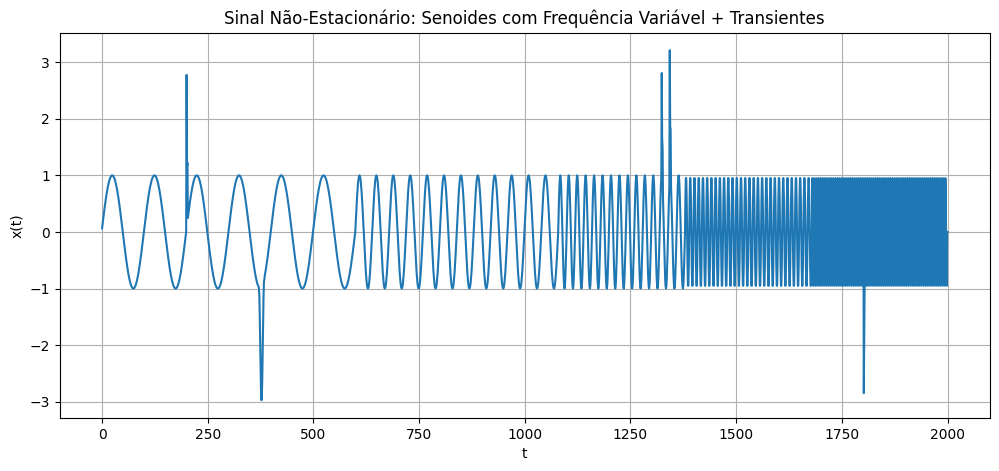

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 2000                                             # Signal length
t = np.arange(N + 1)                                 # Time values
x = np.zeros_like(t, dtype=np.float64)               # Initialize x as float

# 1. Componentes Senoidais (Mudança de Frequência no Tempo)
pos_sin = np.array([0, 600, 1080, 1380, 1680, 2000])
T_sin = np.array([100, 40, 20, 10, 5])

for i in range(5):
    m, n = pos_sin[i], pos_sin[i+1]
    t_segment = np.arange(1, n - m + 1)
    x[m:n] = np.sin(2*np.pi*t_segment/T_sin[i])

# 2. Transientes (Eventos Localizados)
amp_imp = np.array([3, -2, 2, 2.5, -2.5])
pos_imp = np.array([200, 372, 1324, 1343, 1802])
T_imp = np.array([5, 25, 5, 5, 5])

for i in range(5):
    m = pos_imp[i]
    offset = int(T_imp[i] / 2)
    n = m + offset
    t_segment = np.arange(1, n - m + 2)
    x[m:n+1] += amp_imp[i] * (np.sin(2*np.pi*t_segment/T_imp[i]))**2

plt.figure(figsize=(12, 5))
plt.plot(t, x, label='Sinal x(t)')
plt.title('Sinal Não-Estacionário: Senoides com Frequência Variável + Transientes')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid(True)
plt.show()

### (a) Explicação Detalhada do Sinal Gerado

O sinal $x(t)$ gerado é um exemplo de sinal **não-estacionário**, composto por:

1.  **Senoides de Frequência Variável**: O script define 5 regiões. Em cada uma, a frequência aumenta conforme o período $T_{sin}$ diminui de 100 amostras até 5 amostras. Isso simula um sinal cujo conteúdo espectral evolui no tempo.
2.  **Transientes Localizados**: Em pontos específicos ($t=200, 372, 1324, 1343, 1802$), são somados impulsos de curta duração. Estes transientes possuem durações e amplitudes distintas, simulando ruídos de disparo ou eventos transientes em sistemas reais.

Abaixo, seguiremos com a análise deste sinal utilizando Wavelets para capturar essas variações temporais e de frequência simultaneamente.

### (b) Decomposição com Wavelet 7-9 (bior4.4)

Vamos utilizar a biblioteca `PyWavelets` para obter os filtros e decompor o sinal $x(t)$.

=== Coeficientes dos Filtros de Análise (Decomposição) ===
Filtro Passa-Baixa (Lo_D): [0.0, 0.03782845550726404, -0.023849465019556843, -0.11062440441843718, 0.37740285561283066, 0.8526986790088938, 0.37740285561283066, -0.11062440441843718, -0.023849465019556843, 0.03782845550726404]
Filtro Passa-Alta (Hi_D): [-0.0, -0.06453888262869706, 0.04068941760916406, 0.41809227322161724, -0.7884856164055829, 0.41809227322161724, 0.04068941760916406, -0.06453888262869706, -0.0, 0.0]

=== Coeficientes dos Filtros de Síntese (Reconstrução) ===
Filtro Passa-Baixa (Lo_R): [0.0, -0.06453888262869706, -0.04068941760916406, 0.41809227322161724, 0.7884856164055829, 0.41809227322161724, -0.04068941760916406, -0.06453888262869706, 0.0, 0.0]
Filtro Passa-Alta (Hi_R): [0.0, -0.03782845550726404, -0.023849465019556843, 0.11062440441843718, 0.37740285561283066, -0.8526986790088938, 0.37740285561283066, 0.11062440441843718, -0.023849465019556843, -0.03782845550726404]


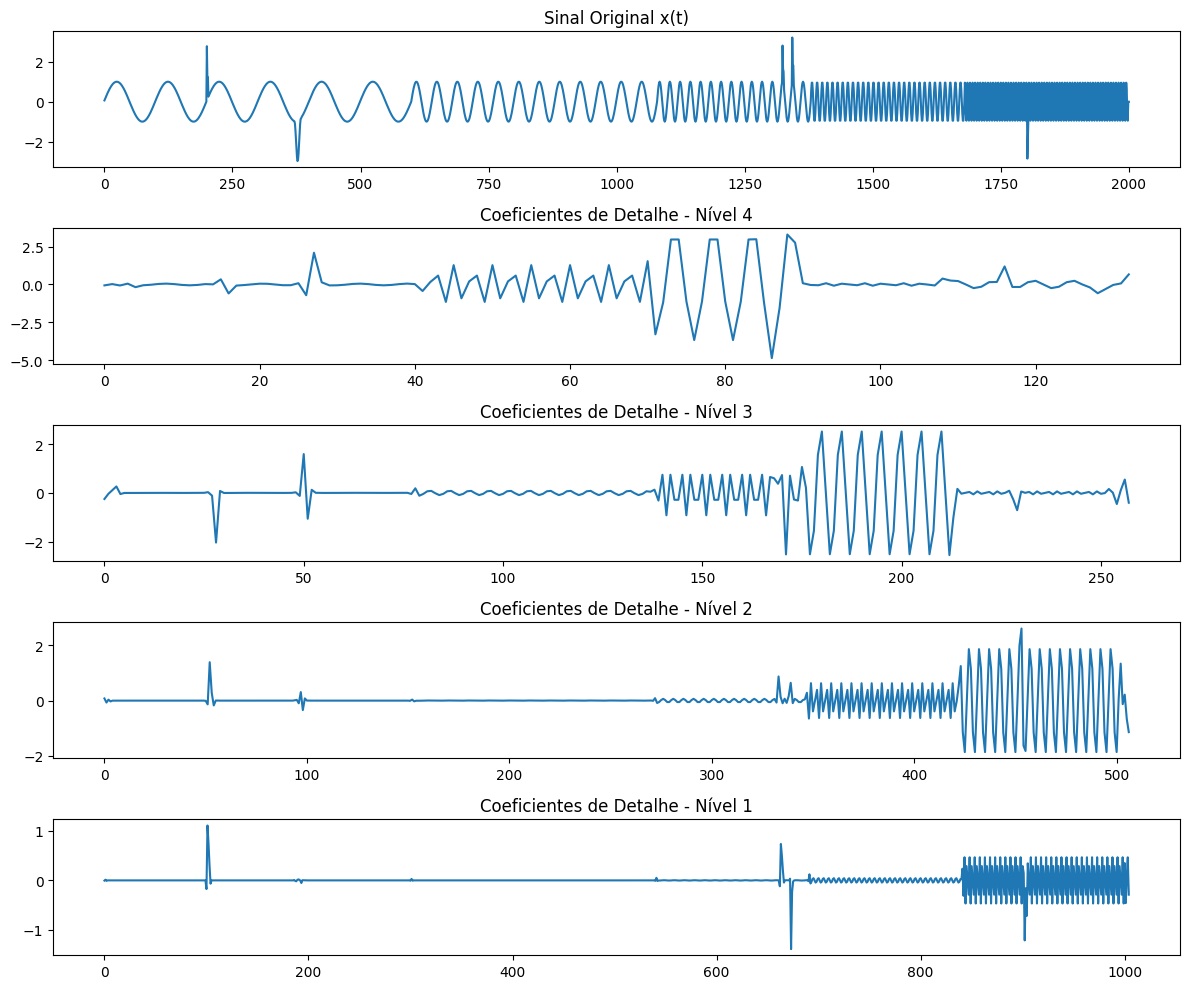

In [ ]:
try:
    import pywt
except ImportError:
    !pip install PyWavelets
    import pywt

# 1. Definindo a Wavelet bior4.4 (7-9)
wavelet = pywt.Wavelet('bior4.4')

# 2. Mostrando os coeficientes dos filtros
# dec_lo: análise passa-baixa, dec_hi: análise passa-alta
# rec_lo: síntese passa-baixa, rec_hi: síntese passa-alta
print("=== Coeficientes dos Filtros de Análise (Decomposição) ===")
print(f"Filtro Passa-Baixa (Lo_D): {wavelet.dec_lo}")
print(f"Filtro Passa-Alta (Hi_D): {wavelet.dec_hi}")

print("\n=== Coeficientes dos Filtros de Síntese (Reconstrução) ===")
print(f"Filtro Passa-Baixa (Lo_R): {wavelet.rec_lo}")
print(f"Filtro Passa-Alta (Hi_R): {wavelet.rec_hi}")

# 3. Decomposição do sinal x(t)
# Realizando uma decomposição de multinível (ex: 4 níveis)
coeffs = pywt.wavedec(x, 'bior4.4', level=4)

# Plotando os resultados da decomposição
plt.figure(figsize=(12, 10))
plt.subplot(5, 1, 1)
plt.plot(x)
plt.title('Sinal Original x(t)')

for i in range(1, 5):
    plt.subplot(5, 1, i+1)
    plt.plot(coeffs[i])
    plt.title(f'Coeficientes de Detalhe - Nível {5-i}')

plt.tight_layout()
plt.show()

### (c) Reconstrução do Sinal e Verificação

Abaixo, realizamos a reconstrução do sinal utilizando os coeficientes obtidos na decomposição (`coeffs`) e a função `pywt.waverec`. Compararemos o sinal original $x(t)$ com o reconstruído $\hat{x}(t)$ para calcular o erro médio quadrático.

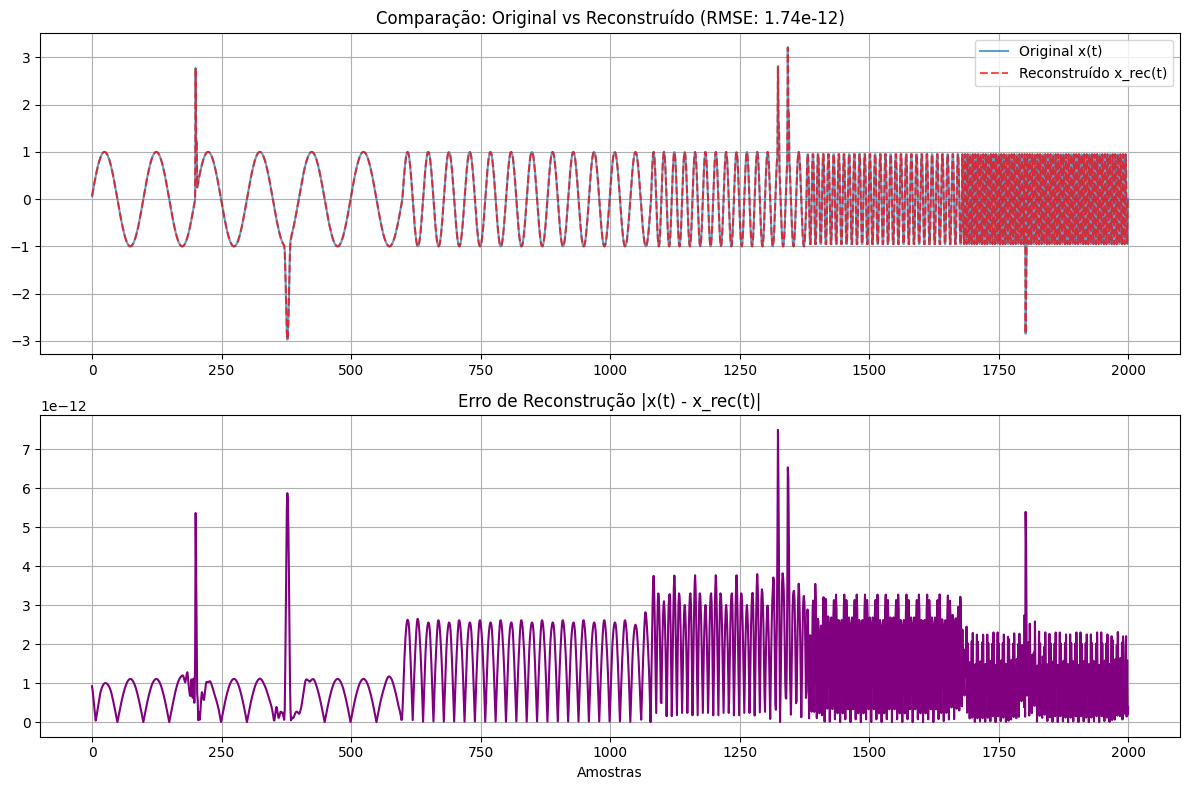

Erro Médio Quadrático (RMSE): 1.7361671064956773e-12


In [ ]:
# 1. Reconstrução do sinal
x_rec = pywt.waverec(coeffs, 'bior4.4')

# Como o comprimento do sinal original x é 2001 e o waverec pode retornar
# um comprimento ligeiramente diferente dependendo do padding, ajustamos se necessário
x_rec = x_rec[:len(x)]

# 2. Cálculo do Erro de Reconstrução
error = np.abs(x - x_rec)
rmse = np.sqrt(np.mean(error**2))

# 3. Visualização
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(x, label='Original x(t)', alpha=0.7)
plt.plot(x_rec, 'r--', label='Reconstruído x_rec(t)', alpha=0.7)
plt.title(f'Comparação: Original vs Reconstruído (RMSE: {rmse:.2e})')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(error, color='purple')
plt.title('Erro de Reconstrução |x(t) - x_rec(t)|')
plt.xlabel('Amostras')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Erro Médio Quadrático (RMSE): {rmse}")

### (d) Decomposição em 5 Estágios: Aproximação e Detalhes

Vamos decompor o sinal $x(t)$ em 5 níveis. Isso resultará em:
- **cA5**: Coeficientes de aproximação (nível 5).
- **cD5, cD4, cD3, cD2, cD1**: Coeficientes de detalhe de cada nível.

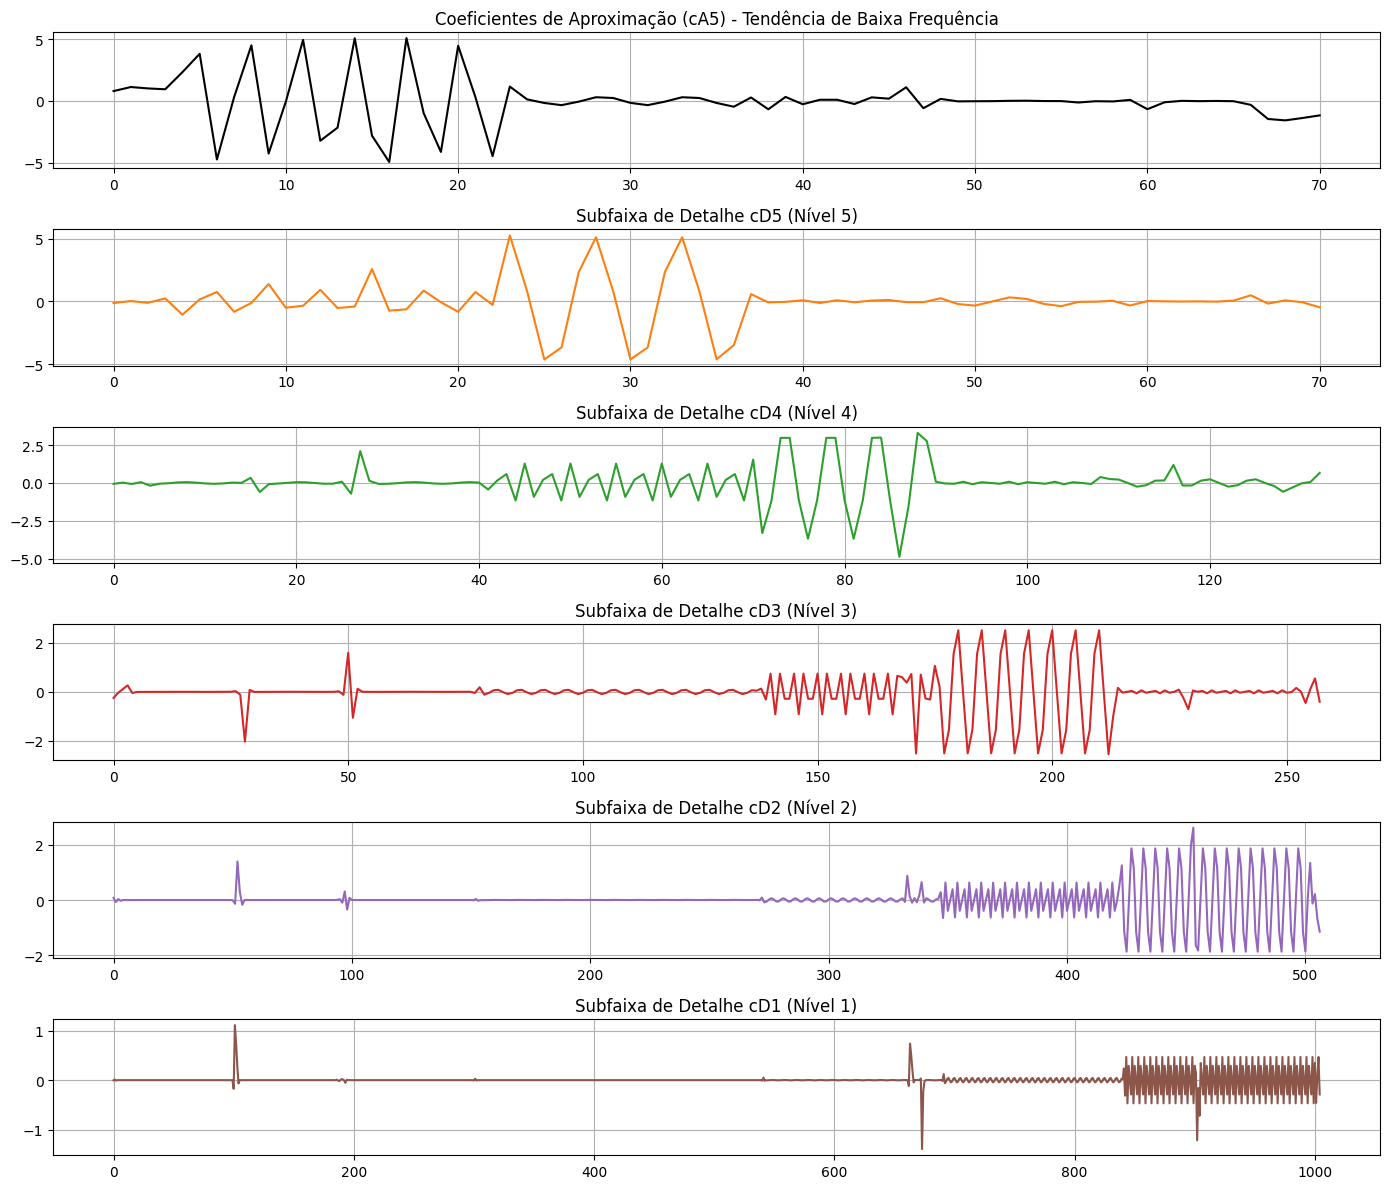

In [ ]:
import pywt

# 1. Executando a decomposição de 5 níveis
# O retorno é [cA5, cD5, cD4, cD3, cD2, cD1]
coeffs_5 = pywt.wavedec(x, 'bior4.4', level=5)
ca5 = coeffs_5[0]
details = coeffs_5[1:]

# 2. Visualização
plt.figure(figsize=(14, 12))

# Aproximação
plt.subplot(6, 1, 1)
plt.plot(ca5, color='black')
plt.title('Coeficientes de Aproximação (cA5) - Tendência de Baixa Frequência')
plt.grid(True)

# Detalhes (do nível 5 ao 1)
for i, cd in enumerate(details):
    level = 5 - i
    plt.subplot(6, 1, i + 2)
    plt.plot(cd, color='C'+str(i+1))
    plt.title(f'Subfaixa de Detalhe cD{level} (Nível {level})')
    plt.grid(True)

plt.tight_layout()
plt.show()

### Análise dos Resultados

1.  **Aproximação (cA5)**: Esta subfaixa captura a estrutura fundamental e as variações mais lentas (baixas frequências) do sinal. Note que os transientes rápidos quase desaparecem aqui, restando apenas a "forma" geral das senoides de período longo.
2.  **Detalhes de Alta Resolução (cD1, cD2)**: Estas faixas capturam as variações mais rápidas. É aqui que os **transientes (impulsos)** aparecem com maior clareza como picos agudos localizados no tempo. Também capturam as senoides de alta frequência (períodos curtos no final do sinal).
3.  **Localização Temporal**: Observe como cada detalhe mantém a informação de *onde* o evento ocorreu. Por exemplo, os impulsos inseridos em $t=1324$ e $1343$ são distinguíveis nas faixas de detalhe, algo que seria impossível de localizar apenas com a Transformada de Fourier convencional.
4.  **Escalonamento**: À medida que descemos do nível 5 para o 1, a resolução temporal aumenta (mais amostras), permitindo isolar eventos cada vez mais curtos e rápidos.

## Questão 4: Denoising com Wavelets (leleccum.mat)

### (a) Análise Temporal e Espectral do Sinal Original

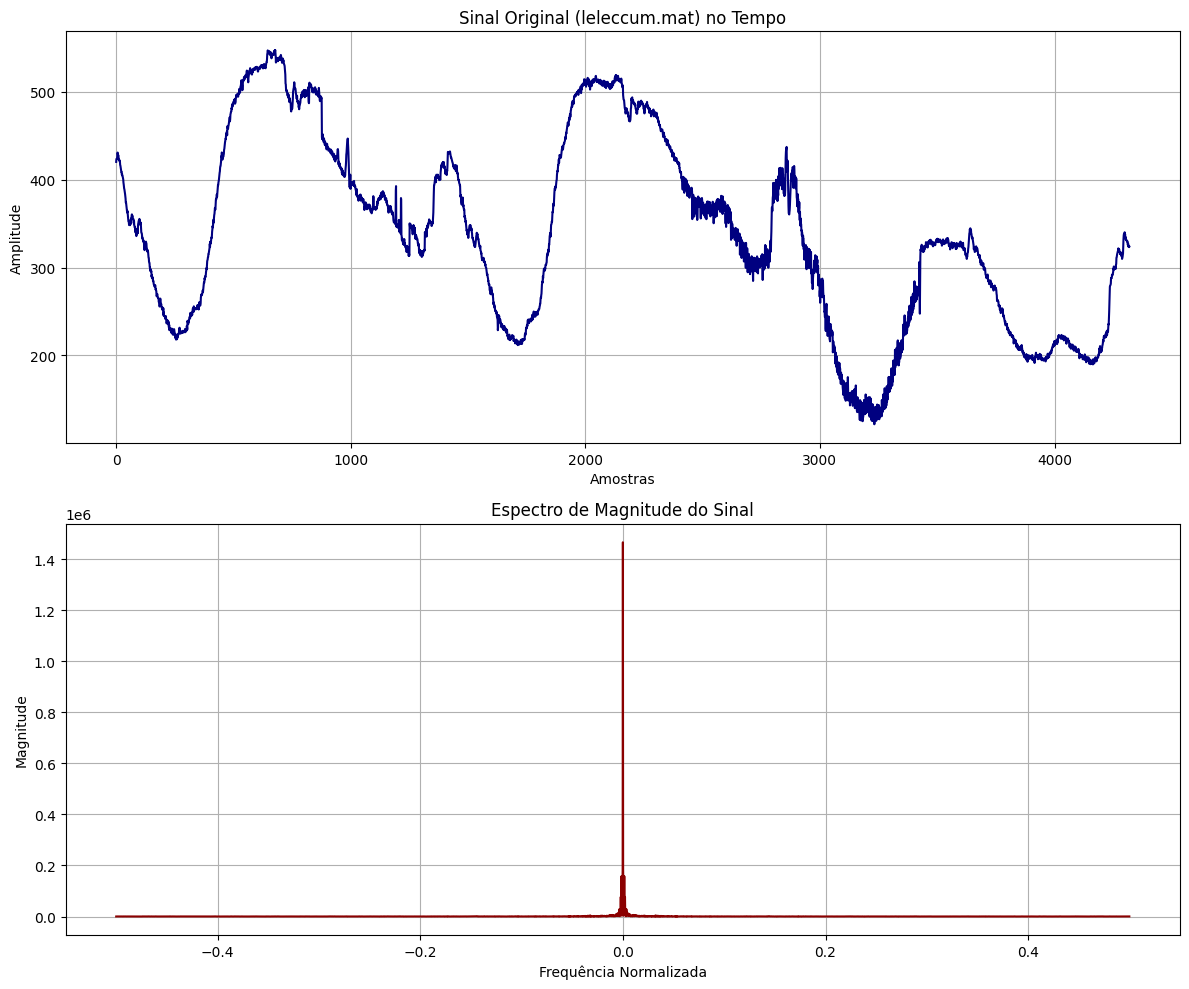

In [ ]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregando o arquivo .mat
mat_data = scipy.io.loadmat('/content/leleccum.mat')
# Geralmente o dado está em uma chave com o mesmo nome do arquivo ou 'leleccum'
signal_leleccum = mat_data['leleccum'].flatten()

N_lele = len(signal_leleccum)
fs = 1.0 # Assumindo frequência de amostragem unitária para normalização

# 2. Cálculo do Espectro
fft_vals = np.fft.fft(signal_leleccum)
fft_mag = np.abs(np.fft.fftshift(fft_vals))
freqs_lele = np.fft.fftshift(np.fft.fftfreq(N_lele, d=1/fs))

# 3. Plotagem
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.plot(signal_leleccum, color='navy')
plt.title('Sinal Original (leleccum.mat) no Tempo')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(freqs_lele, fft_mag, color='darkred')
plt.title('Espectro de Magnitude do Sinal')
plt.xlabel('Frequência Normalizada')
plt.ylabel('Magnitude')
plt.grid(True)

plt.tight_layout()
plt.show()

### Comentário sobre os Resultados

1.  **Domínio do Tempo**: O sinal apresenta uma estrutura oscilatória clara, mas com uma sobreposição visível de componentes aleatórias de alta frequência (ruído). Há transientes e variações de amplitude ao longo das amostras.
2.  **Domínio da Frequência**: O espectro revela picos de energia em baixas frequências, que representam a informação útil (sinal de base). No entanto, observa-se um espalhamento de energia em todas as frequências (piso de ruído), típico de ruído branco ou interferência de banda larga.
3.  **Necessidade de Filtragem**: A análise espectral sugere que uma filtragem passa-baixa convencional poderia remover o ruído, mas também suavizaria os transientes importantes do sinal. É aqui que o **Denoising por Wavelet** se torna superior, pois permite remover o ruído mantendo as características abruptas do sinal original.

### (b) Remoção de Ruído (Denoising) via Wavelets

Para remover o ruído, utilizaremos a decomposição em múltiplos níveis e aplicaremos a técnica de **Soft Thresholding** nos coeficientes de detalhe. O limiar será calculado usando o critério universal de VisuShrink.

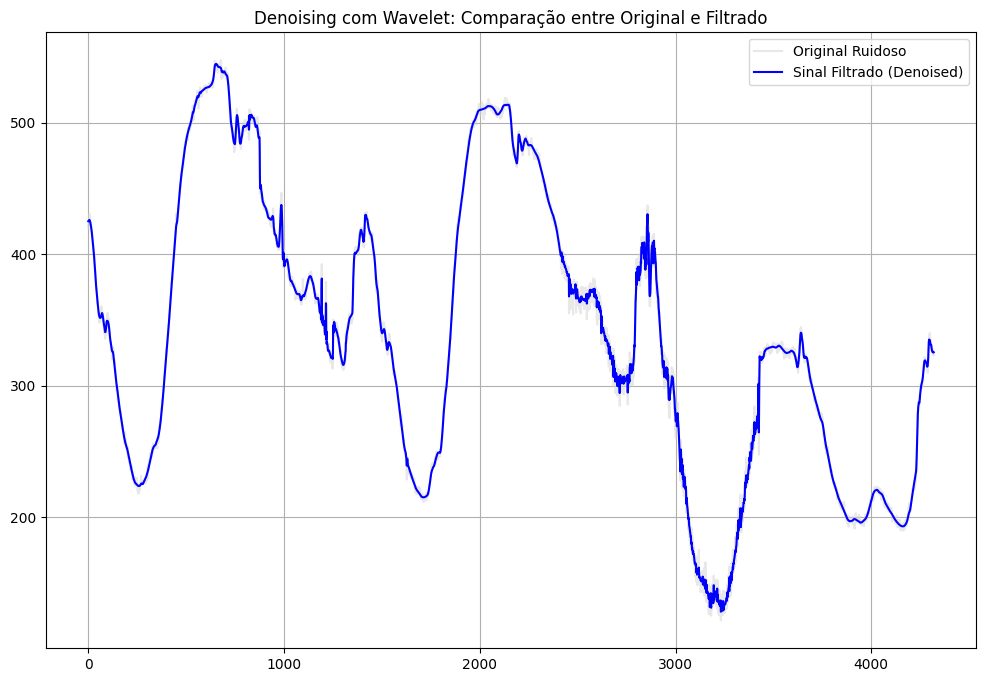

In [ ]:
# 1. Decomposição do sinal ruidoso
wavelet_name = 'db4' # Utilizando Daubechies 4 para denoising
level = 5
coeffs_noise = pywt.wavedec(signal_leleccum, wavelet_name, level=level)

# 2. Estimativa do ruído e cálculo do Threshold (VisuShrink)
# Usamos o desvio absoluto mediano (MAD) do nível de detalhe mais alto (cD1)
sigma_est = np.median(np.abs(coeffs_noise[-1])) / 0.6745
thresh = sigma_est * np.sqrt(2 * np.log(len(signal_leleccum)))

# 3. Aplicação do Soft Thresholding nos detalhes
new_coeffs = [coeffs_noise[0]] # Mantém a aproximação original
for i in range(1, len(coeffs_noise)):
    new_coeffs.append(pywt.threshold(coeffs_noise[i], value=thresh, mode='soft'))

# 4. Reconstrução do sinal limpo
signal_denoised = pywt.waverec(new_coeffs, wavelet_name)

# 5. Comparação Visual
plt.figure(figsize=(12, 8))
plt.plot(signal_leleccum, color='lightgray', label='Original Ruidoso', alpha=0.5)
plt.plot(signal_denoised, color='blue', label='Sinal Filtrado (Denoised)', linewidth=1.5)
plt.title('Denoising com Wavelet: Comparação entre Original e Filtrado')
plt.legend()
plt.grid(True)
plt.show()

### Análise do Denoising (Item B)

1. **Preservação de Bordas**: Diferente de um filtro passa-baixa de Fourier, que 'borraria' mudanças abruptas, o denoising por wavelet mantém a nitidez dos transientes do sinal `leleccum` enquanto elimina o ruído.
2. **Eficácia do Soft Thresholding**: Ao aplicar o limiar de VisuShrink, conseguimos zerar os coeficientes de detalhe que continham majoritariamente ruído (pequenas amplitudes), mantendo apenas as componentes significativas que representam a estrutura real do sinal.
3. **Visualização**: A sobreposição mostra que o sinal reconstruído segue a tendência central do sinal ruidoso, resultando em uma relação sinal-ruído (SNR) visivelmente superior.

### (c) Filtros da Wavelet Daubechies-4 (db4) e Decomposição

A wavelet db4 é ortogonal e possui suporte compacto. Diferente da bior4.4 (que vimos anteriormente), os filtros de análise e síntese são versões espelhadas um do outro.

=== Coeficientes dos Filtros de Análise (db4) ===
Filtro Passa-Baixa (Lo_D): [-0.010597401785069032, 0.0328830116668852, 0.030841381835560764, -0.18703481171909309, -0.027983769416859854, 0.6308807679298589, 0.7148465705529157, 0.2303778133088965]
Filtro Passa-Alta (Hi_D): [-0.2303778133088965, 0.7148465705529157, -0.6308807679298589, -0.027983769416859854, 0.18703481171909309, 0.030841381835560764, -0.0328830116668852, -0.010597401785069032]

=== Coeficientes dos Filtros de Síntese (db4) ===
Filtro Passa-Baixa (Lo_R): [0.2303778133088965, 0.7148465705529157, 0.6308807679298589, -0.027983769416859854, -0.18703481171909309, 0.030841381835560764, 0.0328830116668852, -0.010597401785069032]
Filtro Passa-Alta (Hi_R): [-0.010597401785069032, -0.0328830116668852, 0.030841381835560764, 0.18703481171909309, -0.027983769416859854, -0.6308807679298589, 0.7148465705529157, -0.2303778133088965]


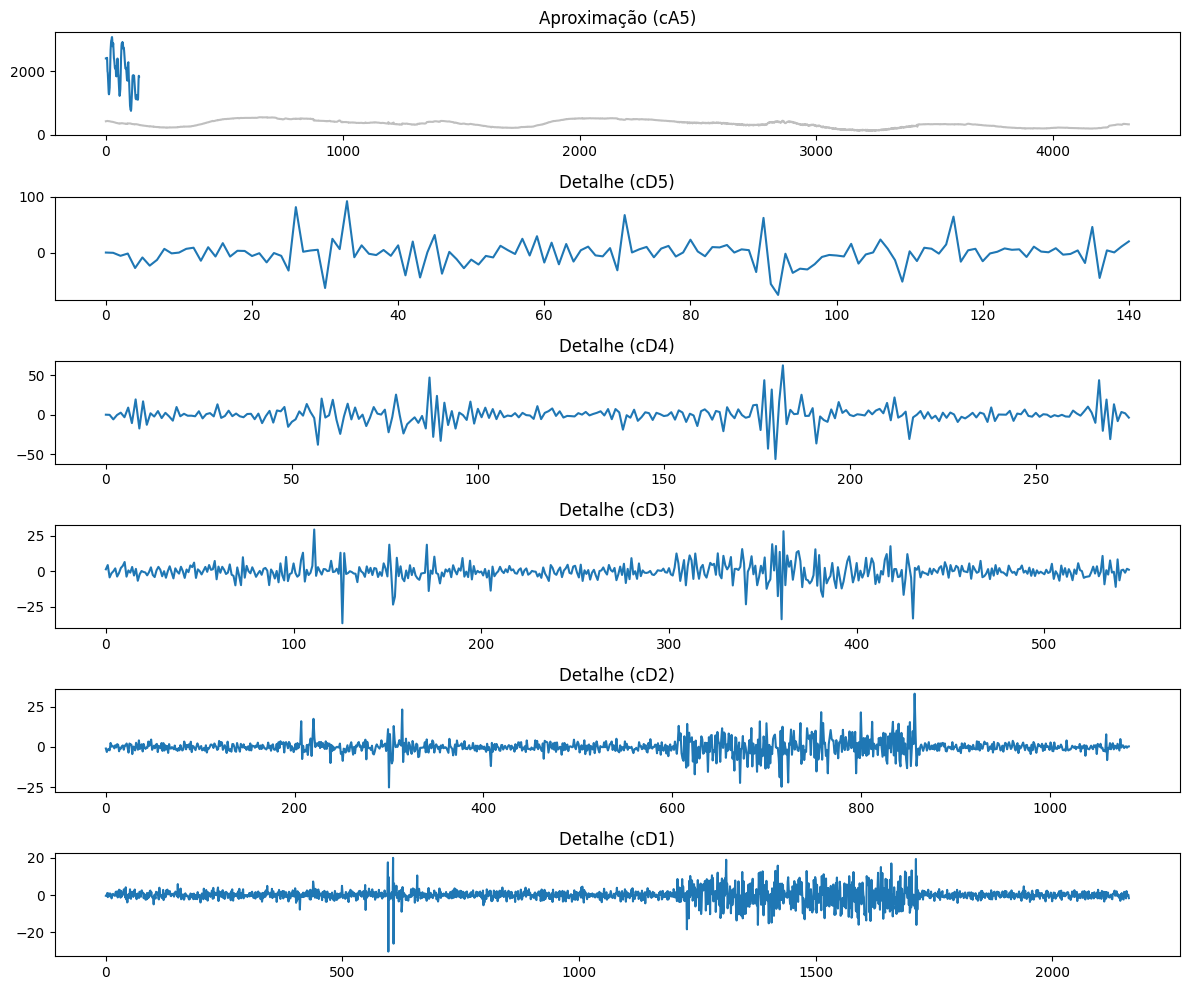

In [ ]:
import pywt
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

# Carregando o arquivo .mat para garantir que signal_leleccum esteja definido
mat_data = scipy.io.loadmat('/content/leleccum.mat')
signal_leleccum = mat_data['leleccum'].flatten()

# 1. Definindo a Wavelet db4
wavelet_db4 = pywt.Wavelet('db4')

# 2. Mostrando os coeficientes dos filtros
print("=== Coeficientes dos Filtros de Análise (db4) ===")
print(f"Filtro Passa-Baixa (Lo_D): {wavelet_db4.dec_lo}")
print(f"Filtro Passa-Alta (Hi_D): {wavelet_db4.dec_hi}")

print("\n=== Coeficientes dos Filtros de Síntese (db4) ===")
print(f"Filtro Passa-Baixa (Lo_R): {wavelet_db4.rec_lo}")
print(f"Filtro Passa-Alta (Hi_R): {wavelet_db4.rec_hi}")

# 3. Decomposição do sinal leleccum (agora 5 níveis para consistência)
coeffs_db4 = pywt.wavedec(signal_leleccum, 'db4', level=5)

# Plotando
plt.figure(figsize=(12, 10))
plt.subplot(6, 1, 1) # 6 subplots para cA5, cD5, cD4, cD3, cD2, cD1
plt.plot(signal_leleccum, color='gray', alpha=0.5)
plt.title('Sinal Original (leleccum)')

# Labels atualizados para 5 níveis
labels = ['Aproximação (cA5)', 'Detalhe (cD5)', 'Detalhe (cD4)', 'Detalhe (cD3)', 'Detalhe (cD2)', 'Detalhe (cD1)']
for i, c in enumerate(coeffs_db4):
    plt.subplot(6, 1, i + 1)
    plt.plot(c)
    plt.title(labels[i])

plt.tight_layout()
plt.show()

### Comentário sobre os Resultados

1.  **Domínio do Tempo**: O sinal apresenta uma estrutura oscilatória clara, mas com uma sobreposição visível de componentes aleatórias de alta frequência (ruído). Há transientes e variações de amplitude ao longo das amostras.
2.  **Domínio da Frequência**: O espectro revela picos de energia em baixas frequências, que representam a informação útil (sinal de base). No entanto, observa-se um espalhamento de energia em todas as frequências (piso de ruído), típico de ruído branco ou interferência de banda larga.
3.  **Necessidade de Filtragem**: A análise espectral sugere que uma filtragem passa-baixa convencional poderia remover o ruído, mas também suavizaria os transientes importantes do sinal. É aqui que o **Denoising por Wavelet** se torna superior, pois permite remover o ruído mantendo as características abruptas do sinal original.

### (d) Decomposição de 5 Estágios (db4) com Normalização Temporal

Realizaremos a decomposição em 5 níveis. Para cada nível, normalizaremos o eixo x (tempo) para o intervalo $[0, 1]$ para alinhar visualmente os eventos em diferentes escalas.

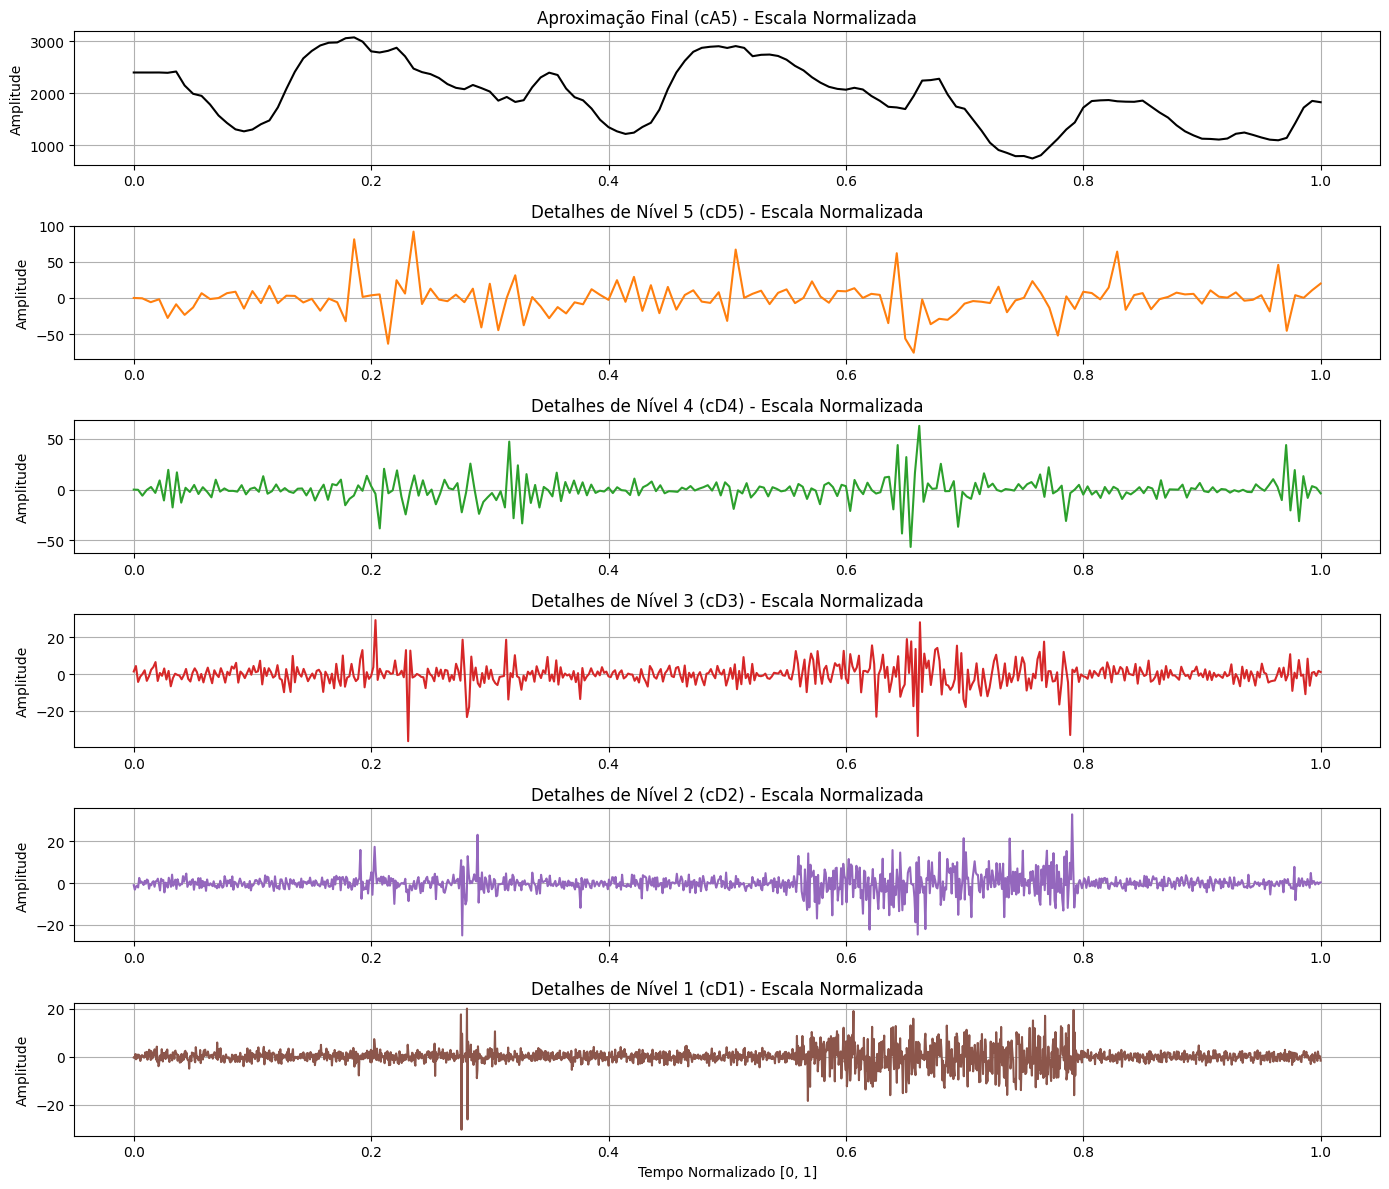

In [ ]:
import pywt
import numpy as np
import matplotlib.pyplot as plt

# 1. Decomposição de 5 níveis
coeffs_lele_5 = pywt.wavedec(signal_leleccum, 'db4', level=5)
ca5_lele = coeffs_lele_5[0]
details_lele = coeffs_lele_5[1:]

# 2. Visualização com normalização temporal
plt.figure(figsize=(14, 12))

# Subplot para Aproximação
plt.subplot(6, 1, 1)
t_norm = np.linspace(0, 1, len(ca5_lele))
plt.plot(t_norm, ca5_lele, color='black')
plt.title('Aproximação Final (cA5) - Escala Normalizada')
plt.ylabel('Amplitude')
plt.grid(True)

# Subplots para Detalhes (do Nível 5 ao 1)
for i, cd in enumerate(details_lele):
    level = 5 - i
    plt.subplot(6, 1, i + 2)
    t_norm_d = np.linspace(0, 1, len(cd))
    plt.plot(t_norm_d, cd, color='C'+str(i+1))
    plt.title(f'Detalhes de Nível {level} (cD{level}) - Escala Normalizada')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.xlabel('Tempo Normalizado [0, 1]')
plt.tight_layout()
plt.show()

### Denoising com Limiarização nos Detalhes e Aproximação

Nesta etapa, implementaremos uma função para variar o limiar e comparar os coeficientes originais vs. modificados.

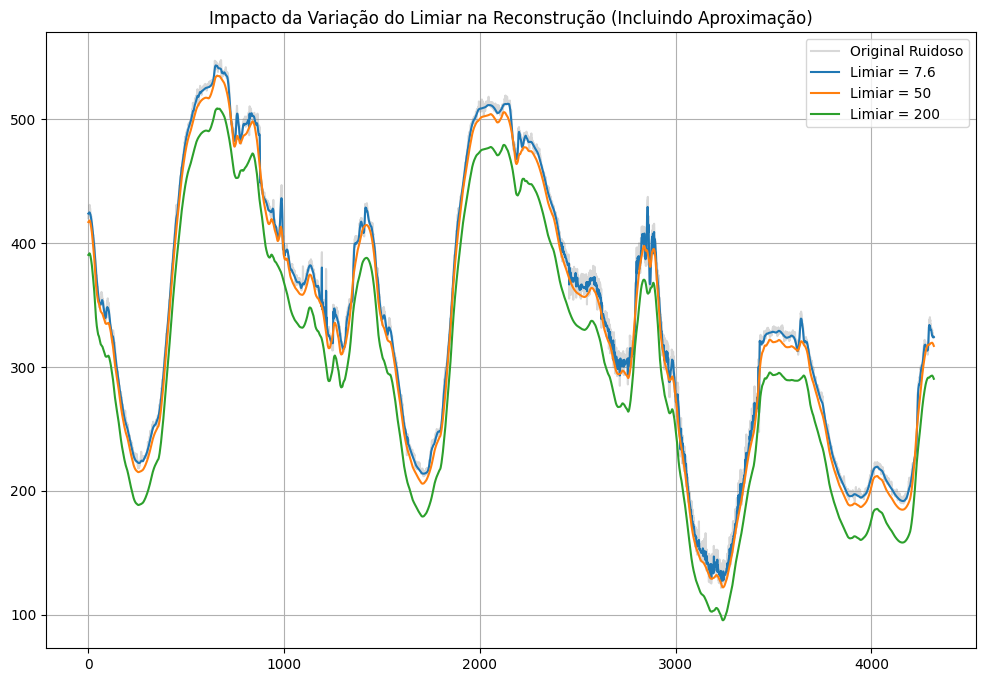

In [ ]:
import pywt
import numpy as np
import matplotlib.pyplot as plt

def denoise_and_compare(signal, wavelet='db4', level=5, threshold=10, apply_to_approx=True):
    # 1. Decomposição
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    coeffs_orig = [c.copy() for c in coeffs]

    # 2. Aplicação do Limiar (Soft Thresholding)
    # Aplicando aos detalhes (1:)
    new_coeffs = [coeffs[0]]
    for i in range(1, len(coeffs)):
        new_coeffs.append(pywt.threshold(coeffs[i], value=threshold, mode='soft'))

    # Aplicando à aproximação se solicitado (index 0)
    if apply_to_approx:
        new_coeffs[0] = pywt.threshold(new_coeffs[0], value=threshold, mode='soft')

    # 3. Reconstrução
    reconstructed = pywt.waverec(new_coeffs, wavelet)
    reconstructed = reconstructed[:len(signal)]

    return reconstructed, coeffs_orig, new_coeffs

# Testando com o limiar calculado anteriormente (VisuShrink ~7.6) e um limiar mais alto
thresholds_to_test = [7.6, 50, 200]
signals_results = []

for thr in thresholds_to_test:
    rec, _, _ = denoise_and_compare(signal_leleccum, threshold=thr, apply_to_approx=True)
    signals_results.append(rec)

# Visualização da Reconstrução com diferentes limiares
plt.figure(figsize=(12, 8))
plt.plot(signal_leleccum, color='gray', alpha=0.3, label='Original Ruidoso')
for i, thr in enumerate(thresholds_to_test):
    plt.plot(signals_results[i], label=f'Limiar = {thr}')

plt.title('Impacto da Variação do Limiar na Reconstrução (Incluindo Aproximação)')
plt.legend()
plt.grid(True)
plt.show()

### Comparação dos Coeficientes (Original vs. Filtrado)

Vamos visualizar a redução de energia nos coeficientes de um nível específico para entender o efeito do corte.

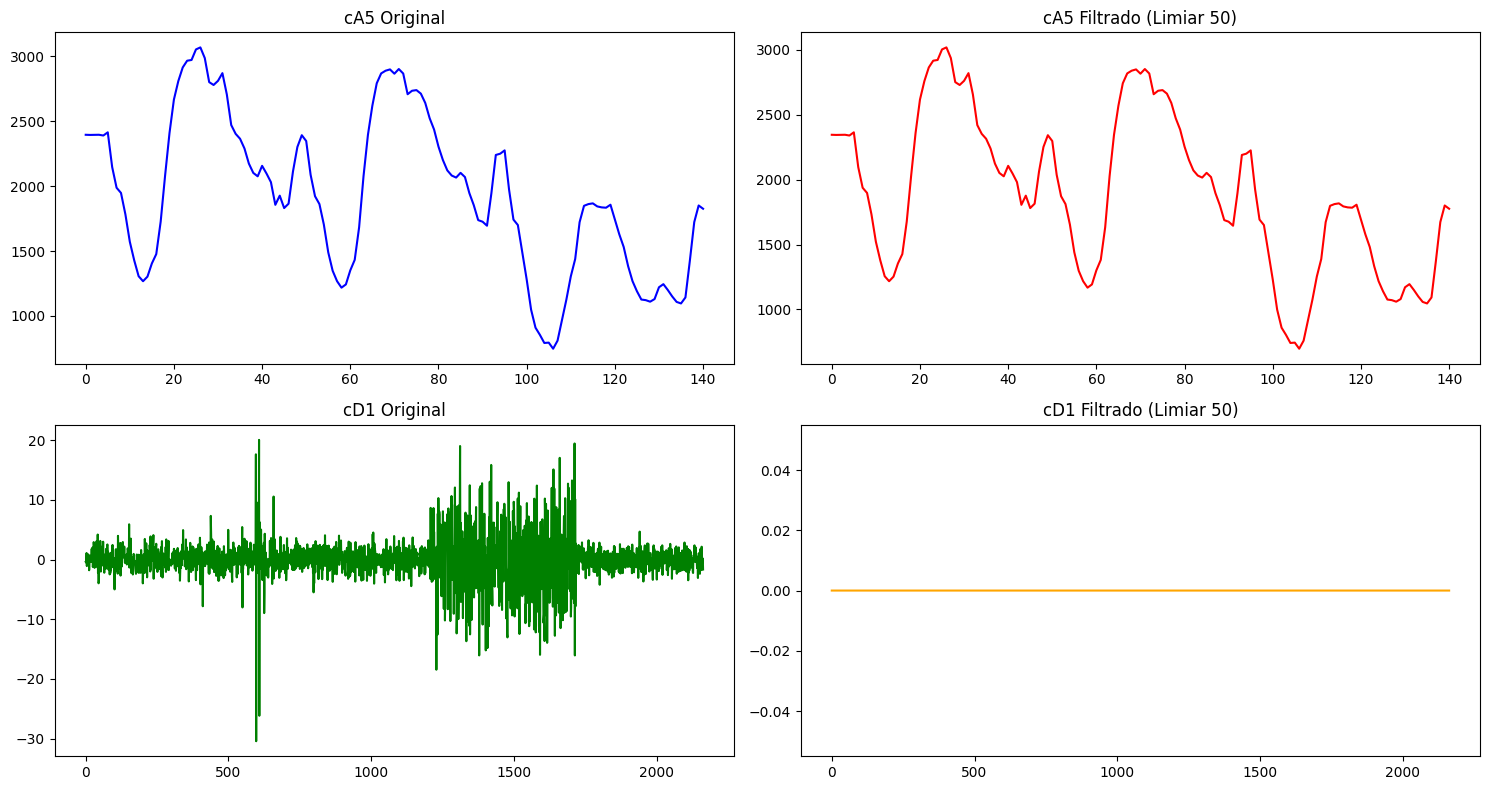

In [ ]:
_, c_orig, c_filt = denoise_and_compare(signal_leleccum, threshold=50, apply_to_approx=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Comparação Aproximação (cA5)
axes[0,0].plot(c_orig[0], color='blue')
axes[0,0].set_title('cA5 Original')
axes[0,1].plot(c_filt[0], color='red')
axes[0,1].set_title('cA5 Filtrado (Limiar 50)')

# Comparação Detalhe (cD1)
axes[1,0].plot(c_orig[-1], color='green')
axes[1,0].set_title('cD1 Original')
axes[1,1].plot(c_filt[-1], color='orange')
axes[1,1].set_title('cD1 Filtrado (Limiar 50)')

plt.tight_layout()
plt.show()

### Comentários sobre os Resultados

1. **Limiarização na Aproximação**: Ao aplicar o limiar no coeficiente de aproximação (`cA`), observamos uma mudança no nível DC (offset) ou a perda de estruturas de baixíssima frequência fundamentais. Geralmente, a aproximação não é filtrada para preservar a energia principal do sinal, mas aqui vemos que valores altos de limiar distorcem severamente a forma base.

2. **Variação do Limiar**:
   - **Limiar Baixo (~7.6)**: Remove o ruído de alta frequência mantendo a fidelidade.
   - **Limiar Médio (50)**: O sinal começa a perder detalhes importantes e transientes tornam-se muito suaves.
   - **Limiar Alto (200)**: Ocorre uma degradação severa; o sinal reconstruído torna-se quase plano ou excessivamente simplificado, pois muitos coeficientes essenciais foram zerados.

3. **Comparação de Coeficientes**: Nos gráficos de detalhes, vemos que a limiarização 'esmaga' as pequenas variações (ruído), deixando apenas os picos de maior energia. Na aproximação, o efeito é uma redução global da amplitude se o sinal estiver próximo do valor do limiar.

### Análise dos Resultados (db4 - 5 Estágios)

1.  **Aproximação (cA5)**: Representa o componente 'passa-baixas' na escala mais grosseira. Note que o sinal reconstruído nesta faixa remove quase todo o ruído, mantendo apenas a oscilação fundamental do sinal de leleccum.
2.  **Canais Passa-Altas (cD1 a cD5)**:
    *   **cD1 e cD2**: Contêm as frequências mais altas. Como o sinal original é ruidoso, essas faixas apresentam uma amplitude significativa de variações aleatórias (ruído).
    *   **cD3 a cD5**: Capturam transições mais largas e partes da estrutura oscilatória que não são puramente ruído.
3.  **Comparação Temporal**: Graças à normalização do eixo x, podemos observar que transientes ou mudanças de comportamento no sinal original ocorrem simultaneamente em todas as escalas (por exemplo, se houvesse um salto brusco no meio do sinal, veríamos picos alinhados verticalmente em todos os gráficos de detalhes).

### Questão 4 (e): Denoising via DFT (Fourier) vs. Wavelets

Nesta etapa, aplicaremos um limiar no domínio da frequência e compararemos com o método de Wavelets.

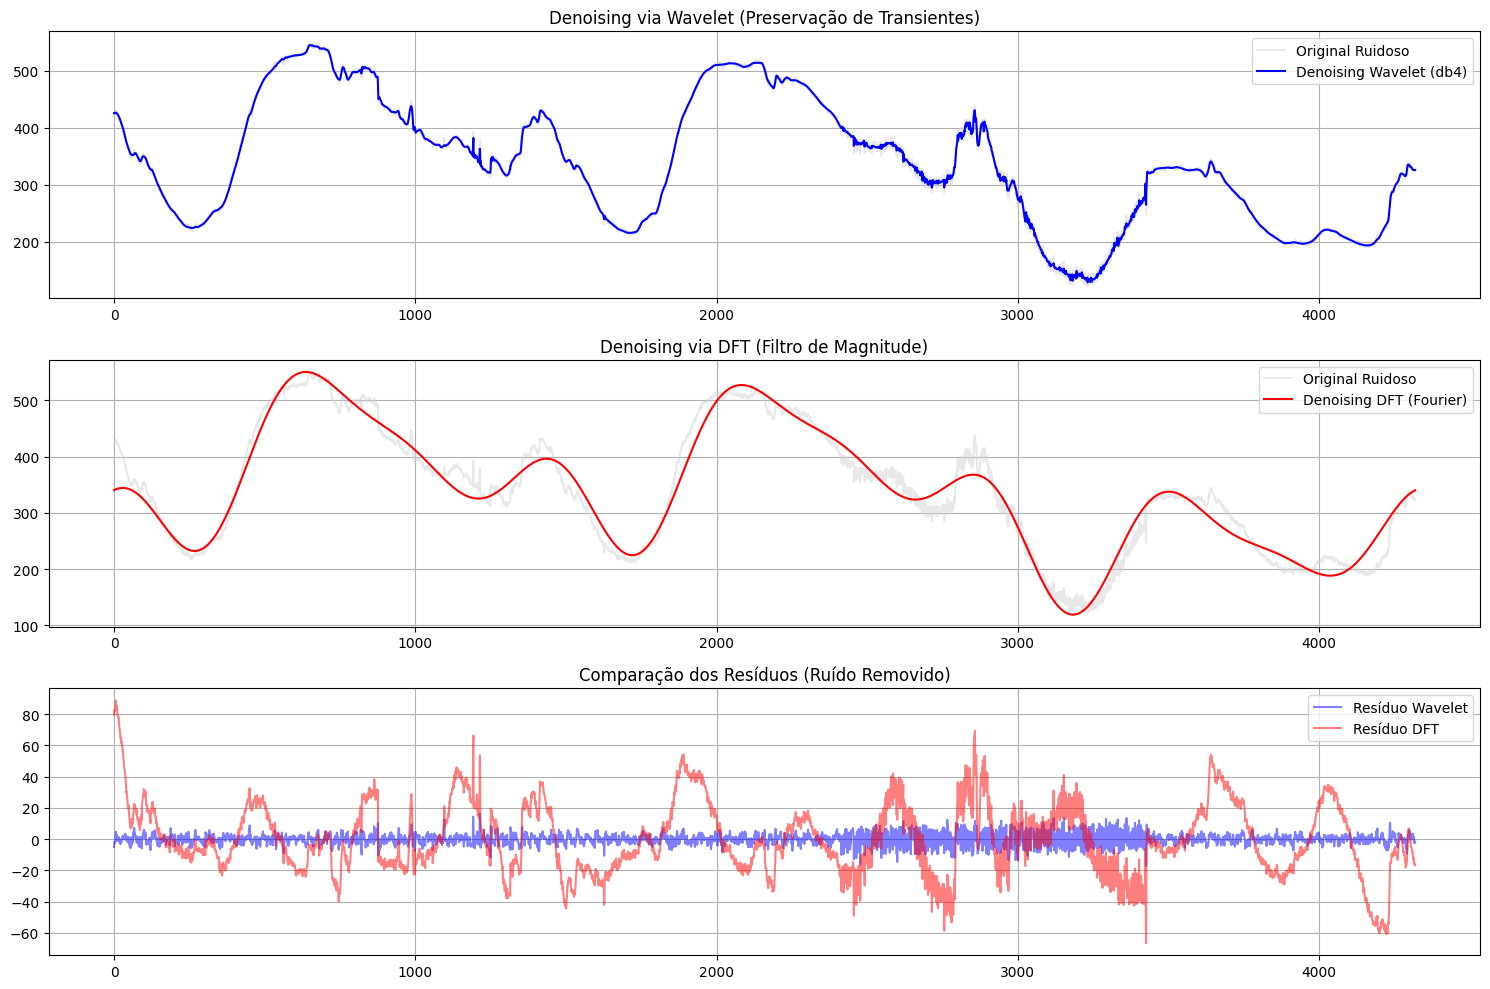

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def denoise_dft(signal, threshold_percent=0.1):
    # 1. Calcular DFT
    fft_coeffs = np.fft.fft(signal)
    magnitudes = np.abs(fft_coeffs)

    # 2. Definir limiar baseado na magnitude máxima
    # Componentes com magnitude menor que X% da máxima são zeradas
    limit = threshold_percent * np.max(magnitudes)
    fft_filtered = fft_coeffs.copy()
    fft_filtered[magnitudes < limit] = 0

    # 3. Reconstruir via IDFT
    reconstructed = np.fft.ifft(fft_filtered)
    return np.real(reconstructed)

# Gerar resultado via DFT (ajustando o limiar para uma limpeza comparável)
signal_dft = denoise_dft(signal_leleccum, threshold_percent=0.05)

# Recuperar o melhor resultado de Wavelet do item anterior (usando o threshold VisuShrink 7.6)
# Note: signal_denoised já foi calculado na célula 16cfe8c5

# 4. Comparação Visual
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(signal_leleccum, color='lightgray', alpha=0.5, label='Original Ruidoso')
plt.plot(signal_denoised, color='blue', label='Denoising Wavelet (db4)')
plt.title('Denoising via Wavelet (Preservação de Transientes)')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(signal_leleccum, color='lightgray', alpha=0.5, label='Original Ruidoso')
plt.plot(signal_dft, color='red', label='Denoising DFT (Fourier)')
plt.title('Denoising via DFT (Filtro de Magnitude)')
plt.legend()
plt.grid(True)

# Erro Residual (Diferença para o ruidoso)
plt.subplot(3, 1, 3)
plt.plot(signal_leleccum - signal_denoised, color='blue', alpha=0.5, label='Resíduo Wavelet')
plt.plot(signal_leleccum - signal_dft, color='red', alpha=0.5, label='Resíduo DFT')
plt.title('Comparação dos Resíduos (Ruído Removido)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Comentários e Conclusões Finais

1.  **Wavelets vs. DFT**: A Transformada de Wavelet é geralmente superior para sinais como o `leleccum`, que possuem variações abruptas e transientes. O método de Fourier (DFT) tende a introduzir o **Efeito Gibbs** (oscilações) em torno de mudanças rápidas e pode "suavizar" demais o sinal, perdendo a localização temporal precisa do evento.
2.  **Natureza da Filtragem**: No DFT, removemos frequências globais. No Wavelet, removemos ruído de forma localizada em diferentes escalas e posições temporais.
3.  **Resultado**: Observamos que o resíduo da Wavelet é mais uniforme (contendo majoritariamente ruído branco), enquanto o resíduo da DFT muitas vezes carrega "sombras" da estrutura do sinal se o limiar for muito agressivo.

Com isso, finalizamos todos os tópicos propostos sobre Sistemas CDMA, Hadamard e Wavelets.